# Import Packages

In [20]:
# 1. Import Packages

# Standard Library
import os
import warnings

# Scientific Computing and Data Analysis
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as scipy_stats
from scipy import stats
from jenkspy import jenks_breaks

# Geospatial and Cartography
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import regionmask

# Visualization and Styling
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, to_rgba
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator, FuncFormatter, MaxNLocator
from matplotlib.transforms import blended_transform_factory
import seaborn as sns
from IPython.display import display

# Jupyter Notebook Configuration
%matplotlib inline
warnings.filterwarnings('ignore', category=UserWarning, module='cartopy')
pd.options.display.max_columns = None

In [21]:
# 2. Paths and Plotting Settings
NOTEBOOK_DIR = os.path.abspath(_dh[0])
print(NOTEBOOK_DIR)
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'FigData')
FIGURE_DIR = os.path.join(NOTEBOOK_DIR, 'Figure')

# Change the working directory to the input data location
os.chdir(DATA_DIR)

# Font embedding for editable text in exported PDF/EPS
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Figure size presets in inches
DOUBLE_COLUMN_FIG_WIDTH = 7.09  # Double column
SINGLE_COLUMN_FIG_WIDTH = 3.54  # Single column

# Global matplotlib parameters
mpl.rcParams['figure.figsize'] = [3.54, 2.36]
mpl.rcParams['figure.constrained_layout.use'] = True
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['axes.titlesize'] = 10
mpl.rcParams['axes.titlepad'] = 4
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'

/work/ch0636/g300138/LowFlowHeatWave/CompoundLowFlowHeatWave


# Mapping Helper Function

In [22]:
def create_map_features_adder(extent=[-9, 27, 35.6, 71], 
                              land_color='#FFFFFF', 
                              ocean_color='#FFFFFF',
                              coastline_color='#000000',
                              coastline_linewidth=0.7):
    """
    Create a reusable function to add map features to any axis.
    
    This factory function returns a closure that can be used to add
    consistent map features across multiple figures.
    
    Parameters
    ----------
    extent : list of float
        Map extent as [lon_min, lon_max, lat_min, lat_max] in 
        PlateCarree coordinates
    land_color : str, optional
        Hex color code for land areas. Default is '#e3e3e3'
    ocean_color : str, optional
        Hex color code for ocean areas. Default is white '#FFFFFF'
    coastline_color : str, optional
        Hex color code for coastline. Default is '#000000'
    coastline_linewidth : float, optional
        Linewidth for coastline. Default is 0.25
    
    Returns
    -------
    function
        A function that takes an axis and adds map features to it
    """
    
    def add_map_features(ax):
        """Add common map features to an axis."""
        global europe_outline
        
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Add ocean with facecolor (zorder=0 - bottom layer)
        ax.add_feature(
            cfeature.OCEAN.with_scale('50m'), 
            facecolor=ocean_color,
            zorder=0
        )
        
        # Add land features with fill (zorder=1 - middle layer)
        ax.add_geometries(
            europe_outline.geometry,
            ccrs.PlateCarree(),
            facecolor=land_color,
            edgecolor='none',
            zorder=1,
            rasterized=True
        )
        
        # Add coastline/outline on top (zorder=3 - top layer)
        ax.add_geometries(
            europe_outline.boundary,
            ccrs.PlateCarree(),
            facecolor='none',
            edgecolor=coastline_color,
            linewidth=coastline_linewidth,
            zorder=3,
            rasterized=True
        )
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=False, linewidth=0.0)
    
    return add_map_features

def set_axis_linewidth(ax, linewidth=0.1):
    """Set the linewidth for all spines of an axis."""
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)

In [23]:
# Create map features adder
add_map_features = create_map_features_adder(
    extent=[-9, 27, 35.6, 71],
    land_color='#FFFFFF',
    ocean_color='#FFFFFF',
    coastline_color='#000000',
    coastline_linewidth=0.8
)

# Colorbar

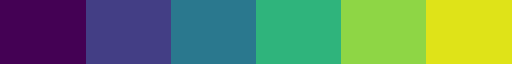

In [24]:
colors_hex_viridis=['#440154', '#433e85','#2a788e','#2fb47c','#8ed645','#dfe318']
viridis_mod=ListedColormap(colors_hex_viridis)
viridis_mod

# European Outline

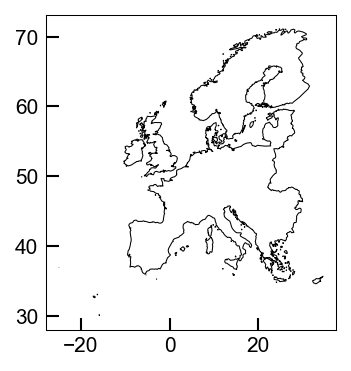

In [25]:
europe_outline = gpd.read_file(os.path.join(DATA_DIR, 'europe_outline.gpkg'))

# Plot to verify
europe_outline.boundary.plot(edgecolor='black', linewidth=0.5)
plt.show()

# Prudence Region

<regionmask.Regions 'PRUDENCE'>
Source:   Christensen and Christensen, 2007, Climatic Change 81:7-30 (https:/...
overlap:  True

Regions:
1 BI     British Isles
2 IP Iberian Peninsula
3 FR            France
4 ME        Mid-Europe
5 SC       Scandinavia
6 AL              Alps
7 MD     Mediterranean
8 EA    Eastern Europe

[8 regions]


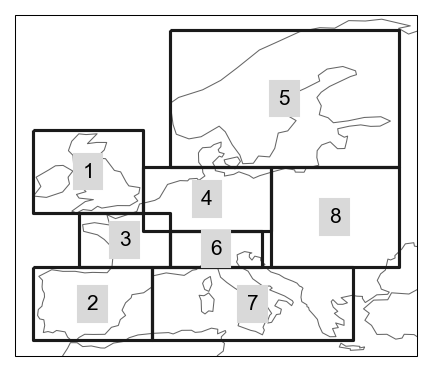

In [26]:
# Load region mask
europe_PRUDENCE_regions = regionmask.defined_regions.prudence
print(europe_PRUDENCE_regions)
europe_PRUDENCE_regions.plot();plt.show()

# Stats function

In [27]:
def compute_region_stats(
    data_old,
    data_new,
    region_mask,
    var_name: str       = 'mean_annual_frequency',
    fill_value: float   = -99999,
    duration_vars: list = None,
    duration_unit: str  = 'seconds',
):
    """
    Compute per-region descriptive statistics from spatially masked xarray data.

    Used by plot_strip_8x4.

    Parameters
    ----------
    data_old : xr.Dataset or xr.DataArray
        Data for the old period (e.g. 1961–1990).
    data_new : xr.Dataset or xr.DataArray
        Data for the new period (e.g. 1991–2020).
    region_mask : regionmask.Regions
        The regionmask Regions object.
    var_name : str
        Variable to extract if a Dataset is passed.
    fill_value : float
        Fill value to exclude alongside NaNs (default -99999).
    duration_vars : list or None
        Variable names whose raw values should be converted to days.
    duration_unit : {'seconds', 'nanoseconds', 'hours', 'days'}
        Storage unit of duration variables (converted to days automatically).

    Returns
    -------
    dict
        Nested dict keyed by region abbreviation. Each region dict contains:

        Summary statistics (scalars), used by plot_dot_range_8x4:
            med_old / med_new    - median (Q50)
            mean_old / mean_new  - arithmetic mean
            q5_old  / q5_new     - 5th  percentile
            q10_old / q10_new    - 10th percentile
            q25_old / q25_new    - 25th percentile
            q75_old / q75_new    - 75th percentile
            q90_old / q90_new    - 90th percentile
            q95_old / q95_new    - 95th percentile

        Raw arrays, used by plot_strip_8x4 (ignored by plot_dot_range_8x4):
            raw_old  - 1-D numpy array of all valid grid-point values (old)
            raw_new  - 1-D numpy array of all valid grid-point values (new)
    """
    _to_days = {
        'seconds':     1 / 86400,
        'nanoseconds': 1 / 86400e9,
        'hours':       1 / 24,
        'days':        1,
    }
    if duration_unit not in _to_days:
        raise ValueError(
            f"duration_unit must be one of {list(_to_days)}, got '{duration_unit}'"
        )
    scale = _to_days[duration_unit]

    def _extract_var(data, var):
        return data[var] if isinstance(data, xr.Dataset) else data

    da_old = _extract_var(data_old, var_name)
    da_new = _extract_var(data_new, var_name)

    if duration_vars is not None and var_name in duration_vars:
        da_old = da_old * scale
        da_new = da_new * scale

    mask_3d_old = region_mask.mask_3D(da_old)
    mask_3d_new = region_mask.mask_3D(da_new)

    def _region_values(da, mask_3d, region_number):
        masked = da.where(mask_3d.sel(region=region_number))
        flat   = masked.values.ravel()
        valid  = flat[
            (~np.isnan(flat)) &
            (flat != fill_value) &
            (np.abs(flat) < 1e6)
        ]
        return valid

    def _stats(arr):
        return {
            'q5':   float(np.percentile(arr,  5)),
            'q10':  float(np.percentile(arr, 10)),
            'q25':  float(np.percentile(arr, 25)),
            'med':  float(np.percentile(arr, 50)),
            'q75':  float(np.percentile(arr, 75)),
            'q90':  float(np.percentile(arr, 90)),
            'q95':  float(np.percentile(arr, 95)),
            'mean': float(np.mean(arr)),
        }

    out = {}
    for region in region_mask:
        reg           = region.abbrev
        region_number = region.number

        arr_o = _region_values(da_old, mask_3d_old, region_number)
        arr_n = _region_values(da_new, mask_3d_new, region_number)

        if arr_o.size == 0 or arr_n.size == 0:
            print(f'  ⚠ Warning: region {reg} (index {region_number}) '
                  f'returned no valid grid points.')
            continue

        so = _stats(arr_o)
        sn = _stats(arr_n)

        out[reg] = {
            # summary statistics, used by plot_dot_range_8x4
            'med_old':  so['med'],   'med_new':  sn['med'],
            'mean_old': so['mean'],  'mean_new': sn['mean'],
            'q5_old':   so['q5'],    'q5_new':   sn['q5'],
            'q10_old':  so['q10'],   'q10_new':  sn['q10'],
            'q25_old':  so['q25'],   'q25_new':  sn['q25'],
            'q75_old':  so['q75'],   'q75_new':  sn['q75'],
            'q90_old':  so['q90'],   'q90_new':  sn['q90'],
            'q95_old':  so['q95'],   'q95_new':  sn['q95'],
            # raw arrays, used by plot_strip_8x4
            'raw_old':  arr_o,
            'raw_new':  arr_n,
        }

    return out

# Plotting Function

## Regional Map 1x4

In [28]:
def plot_four_panel_analysis(
    data_past_1,
    data_present_1,
    data_past_2,
    data_present_2,
    variable_name_1,
    variable_name_2,
    bins_map_1=np.arange(0, 5.5, 0.5),
    bins_map_2=np.arange(0, 5.5, 0.5),
    bins_delta=np.array([-1.5, -1.0, -0.5, -0.025, 0.1, 0.025, 1.0, 1.5]),
    yellow_range=(-0.025, 0.025),
    use_nondefault_cmap=True,
    cmap_sequential_1=None,
    cmap_sequential_2=None,
    cmap_sequential_range=(0.1, 0.9),
    extend_colorbar_1='max',
    extend_colorbar_2='max',
    tick_positions_delta=[-3, -1, 0, 1, 3],
    titles=None,
    save_dir=FIGURE_DIR,
    filename=None,
    save_formats=['jpg', 'pdf'],
    dpi=300,
    figsize=(260, 120),  # mm (width, height)
    title_fontsize=12,
    cbar_tick_fontsize=12,
    tick_interval_1=1,
    tick_interval_2=1,
    add_map_features_func=None,
):
    """
    Create a four-panel figure:
      Panel 1: Present period map for dataset 1
      Panel 2: Relative delta map for dataset 1 (present vs past)
      Panel 3: Present period map for dataset 2
      Panel 4: Relative delta map for dataset 2 (present vs past)

    Parameters
    ----------
    data_past_1 : xarray.Dataset or DataArray
        Past period data for dataset 1 (e.g. 1961–1990).
    data_present_1 : xarray.Dataset or DataArray
        Present period data for dataset 1 (e.g. 1991–2020).
    data_past_2 : xarray.Dataset or DataArray
        Past period data for dataset 2.
    data_present_2 : xarray.Dataset or DataArray
        Present period data for dataset 2.
    variable_name_1 : str
        Variable name to extract from dataset 1 (if Dataset).
    variable_name_2 : str
        Variable name to extract from dataset 2 (if Dataset).
    bins_map_1 : array-like
        Colormap bin edges for the sequential map of dataset 1.
    bins_map_2 : array-like
        Colormap bin edges for the sequential map of dataset 2.
    bins_delta : array-like
        Bin edges for the diverging delta colormap (shared by both delta panels).
    yellow_range : tuple
        (min, max) values that map to the neutral yellow colour in the delta map.
    use_nondefault_cmap : bool
        If True, use the supplied cmap_sequential_* objects directly.
        If False, sample from the named colormap over cmap_sequential_range.
    cmap_sequential_1 : str or Colormap or None
        Sequential colormap for dataset-1 maps.
    cmap_sequential_2 : str or Colormap or None
        Sequential colormap for dataset-2 maps.
    cmap_sequential_range : tuple
        (lo, hi) fraction of the colormap to sample when use_nondefault_cmap=False.
    extend_colorbar_1 : str
        'max' or 'both' – controls upper/lower extension for dataset-1 colorbar.
    extend_colorbar_2 : str
        'max' or 'both' – controls upper/lower extension for dataset-2 colorbar.
    tick_positions_delta : list
        Tick positions for the shared delta colorbar.
    titles : dict or None
        Custom panel titles. Keys: 'panel1', 'panel2', 'panel3', 'panel4'.
        Defaults to generic labels if None.
    save_dir : str
        Directory for saved figures.
    filename : str or None
        Base filename (no extension). Figure is not saved when None.
    save_formats : list of str
        File formats to write, e.g. ['jpg', 'pdf'].
    dpi : int
        Resolution for raster formats.
    figsize : tuple
        Figure size in millimetres (width, height).
    title_fontsize : int
        Font size for panel titles and annotations.
    cbar_tick_fontsize : int
        Font size for colorbar tick labels.
    tick_interval_1 : int
        Show every Nth tick on the dataset-1 sequential colorbar.
    tick_interval_2 : int
        Show every Nth tick on the dataset-2 sequential colorbar.
    add_map_features_func : callable or None
        Function ``f(ax)`` that adds cartopy features (coastlines, borders …).
        The European boundary outline drawn inside this function should use
        rasterized=True on its add_geometries call (see create_map_features_adder).

    Returns
    -------
    fig : matplotlib.figure.Figure
    """

    # Helpers
    MM_TO_INCH = 1 / 25.4
    figsize_inches = (figsize[0] * MM_TO_INCH, figsize[1] * MM_TO_INCH)

    mpl.rcParams['xtick.direction'] = 'in'
    mpl.rcParams['ytick.direction'] = 'in'

    FILL_VALUE = -99999
    panel_labels = ['a', 'b', 'c', 'd']
    panel_label_fontsize = title_fontsize - 1

    def _extract(dataset, varname):
        if hasattr(dataset, varname):
            return dataset[varname]
        return dataset

    def _compute_delta(past, present):
        """Relative change: (present - past) / past, masked for FILL_VALUE."""
        valid = (past != FILL_VALUE) & (present != FILL_VALUE)
        delta = xr.full_like(past, FILL_VALUE, dtype=float)
        delta = xr.where(valid & (past != 0),
                         (present - past) / past,
                         delta)
        delta = xr.where(valid & (past == 0), 0, delta)
        return delta

    def _build_seq_norm(bins_map, extend_colorbar, cmap_sequential,
                        use_nondefault_cmap, cmap_sequential_range):
        n_colors = len(bins_map) + 1
        if use_nondefault_cmap and cmap_sequential is not None:
            cmap = cmap_sequential
        else:
            base = plt.get_cmap(cmap_sequential if cmap_sequential else 'plasma')
            colors = base(np.linspace(cmap_sequential_range[0],
                                      cmap_sequential_range[1], n_colors))
            cmap = ListedColormap(colors)

        if extend_colorbar == 'max':
            boundaries = np.concatenate((bins_map, [1e6]))
        else:  # 'both'
            boundaries = np.concatenate(([-99998], bins_map, [1e6]))
            cmap.set_under('#4D4D4D')

        norm = mcolors.BoundaryNorm(boundaries, n_colors)
        return cmap, norm

    def _build_delta_norm(bins_delta, yellow_range):
        boundaries = np.concatenate(([-99998], bins_delta, [1e6]))
        n_colors = len(boundaries) - 1

        negative_bins = bins_delta[bins_delta < yellow_range[0]]
        positive_bins = bins_delta[bins_delta > yellow_range[1]]

        RdYlBu_or = plt.cm.RdYlBu
        extreme_blue  = RdYlBu_or(np.linspace(0.95, 1.00, 1))
        blue_colors   = RdYlBu_or(np.linspace(0.90, 0.70, len(negative_bins)))
        yellow_colors = np.tile(to_rgba('#FFDF20'), (1, 1))
        red_colors    = RdYlBu_or(np.linspace(0.30, 0.10, len(positive_bins)))
        extreme_red   = RdYlBu_or(np.linspace(0.00, 0.05, 1))

        colors = np.vstack([extreme_blue, blue_colors,
                            yellow_colors, red_colors, extreme_red])
        cmap = ListedColormap(colors)
        cmap.set_under('#4D4D4D')
        norm = mcolors.BoundaryNorm(boundaries, n_colors)
        return cmap, norm

    def set_axis_linewidth(ax, linewidth=0.0):
        for spine in ax.spines.values():
            spine.set_linewidth(linewidth)

    def _add_seq_colorbar(fig, im, ax, bins_map, tick_interval, cbar_tick_fontsize):
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                            pad=0.02, shrink=0.9, aspect=20)
        # Rasterize the colorbar filled patches for smaller PDF file size
        cbar.solids.set_rasterized(True)
        cbar.ax.tick_params(labelsize=cbar_tick_fontsize, length=5)
        cbar.set_ticks(bins_map[::tick_interval])
        cbar.set_ticklabels([f'{v:g}' for v in bins_map[::tick_interval]])
        cbar.outline.set_linewidth(0.8)

    def _add_delta_colorbar(fig, im, ax, tick_positions_delta, cbar_tick_fontsize):
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                            pad=0.02, shrink=0.9, aspect=20)
        # Rasterize the colorbar filled patches for smaller PDF file size
        cbar.solids.set_rasterized(True)
        cbar.ax.tick_params(labelsize=cbar_tick_fontsize, length=5)
        cbar.set_ticks(tick_positions_delta)
        cbar.set_ticklabels([f'{x:g}' for x in tick_positions_delta])
        cbar.outline.set_linewidth(0.8)

    # Extract data
    past_1    = _extract(data_past_1,    variable_name_1)
    present_1 = _extract(data_present_1, variable_name_1)
    past_2    = _extract(data_past_2,    variable_name_2)
    present_2 = _extract(data_present_2, variable_name_2)

    delta_1 = _compute_delta(past_1, present_1)
    delta_2 = _compute_delta(past_2, present_2)

    # Colormaps & norms
    cmap_seq_1, norm_seq_1 = _build_seq_norm(
        bins_map_1, extend_colorbar_1,
        cmap_sequential_1, use_nondefault_cmap, cmap_sequential_range)

    cmap_seq_2, norm_seq_2 = _build_seq_norm(
        bins_map_2, extend_colorbar_2,
        cmap_sequential_2, use_nondefault_cmap, cmap_sequential_range)

    cmap_delta, norm_delta = _build_delta_norm(bins_delta, yellow_range)

    # Default titles
    if titles is None:
        titles = {
            'panel1': f'{variable_name_1} — Present',
            'panel2': f'{variable_name_1} — Rel. Δ',
            'panel3': f'{variable_name_2} — Present',
            'panel4': f'{variable_name_2} — Rel. Δ',
        }

    # Figure layout
    fig = plt.figure(figsize=figsize_inches)

    gs = GridSpec(1, 4, figure=fig, wspace=0.1, width_ratios=[1, 1, 1, 1])

    projection = ccrs.LambertConformal(
        central_latitude=53,
        central_longitude=12,
        standard_parallels=(45, 65),
    )

    # map data is rasterized via rasterized=True; titles and tick labels
    # remain as vectors because text artists are never affected by rasterized=True
    common_plot_kw = dict(
        add_colorbar=False,
        transform=ccrs.PlateCarree(),
        zorder=2,
        rasterized=True,
        antialiased=False,
        edgecolors='none',
        linewidth=0,
    )

    # Panel 1 – present, dataset 1
    ax1 = fig.add_subplot(gs[0, 0], projection=projection)
    if add_map_features_func:
        add_map_features_func(ax1)

    im1 = present_1.plot(ax=ax1, cmap=cmap_seq_1, norm=norm_seq_1, **common_plot_kw)
    _add_seq_colorbar(fig, im1, ax1, bins_map_1, tick_interval_1, cbar_tick_fontsize)
    set_axis_linewidth(ax1)
    ax1.set_title(titles['panel1'], fontsize=title_fontsize, pad=4, fontweight='bold')

    # Panel 2 – delta, dataset 1
    ax2 = fig.add_subplot(gs[0, 1], projection=projection)
    if add_map_features_func:
        add_map_features_func(ax2)

    im2 = delta_1.plot(ax=ax2, cmap=cmap_delta, norm=norm_delta, **common_plot_kw)
    _add_delta_colorbar(fig, im2, ax2, tick_positions_delta, cbar_tick_fontsize)
    set_axis_linewidth(ax2)
    ax2.set_title(titles['panel2'], fontsize=title_fontsize, pad=4, fontweight='bold')

    # Panel 3 – present, dataset 2
    ax3 = fig.add_subplot(gs[0, 2], projection=projection)
    if add_map_features_func:
        add_map_features_func(ax3)

    im3 = present_2.plot(ax=ax3, cmap=cmap_seq_2, norm=norm_seq_2, **common_plot_kw)
    _add_seq_colorbar(fig, im3, ax3, bins_map_2, tick_interval_2, cbar_tick_fontsize)
    set_axis_linewidth(ax3)
    ax3.set_title(titles['panel3'], fontsize=title_fontsize, pad=4, fontweight='bold')

    # Panel 4 – delta, dataset 2
    ax4 = fig.add_subplot(gs[0, 3], projection=projection)
    if add_map_features_func:
        add_map_features_func(ax4)

    im4 = delta_2.plot(ax=ax4, cmap=cmap_delta, norm=norm_delta, **common_plot_kw)
    _add_delta_colorbar(fig, im4, ax4, tick_positions_delta, cbar_tick_fontsize)
    set_axis_linewidth(ax4)
    ax4.set_title(titles['panel4'], fontsize=title_fontsize, pad=4, fontweight='bold')

    # Panel labels (a) … (d)
    for ax, label in zip([ax1, ax2, ax3, ax4], panel_labels):
        ax.text(
            0.0, 1.0, f'({label})',
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight='bold',
            va='top', ha='left',
            zorder=100,
        )

    # Save
    if filename is not None:
        os.makedirs(save_dir, exist_ok=True)
        for fmt in save_formats:
            filepath = os.path.join(save_dir, f'{filename}.{fmt}')
            if fmt.lower() in ['jpg', 'jpeg', 'png', 'tiff']:
                fig.savefig(filepath, dpi=dpi, format=fmt, bbox_inches='tight')
            else:
                fig.savefig(filepath, format=fmt, bbox_inches='tight')
            print(f'✓ Saved: {filepath}')
        plt.close(fig)

    return fig

## Regional Map 1x3

In [43]:
def plot_three_panel_analysis(
    data_1961to1990,
    data_1991to2020,
    variable_name,
    bins_map=np.arange(0, 5.5, 0.5),
    bins_delta=np.array([-1.5, -1.0, -0.5, -0.025, 0.1, 0.025, 1.0, 1.5]),
    yellow_range=(-0.025, 0.025),
    use_nondefault_cmap=True,
    cmap_sequential=None,
    cmap_sequential_range=(0.1, 0.9),
    extend_colorbar='max',
    kde_ylim=(0, 1),
    kde_yticks=None,
    kde_xlim=None,
    kde_bounded=False,
    kde_lower_bound=0,
    print_kde_integrals=True,
    tick_positions_delta=[-3, -1, 0, 1, 3],
    titles=None,
    panel_labels=['a', 'b', 'c'],
    save_dir=FIGURE_DIR,
    filename=None,
    save_formats=['jpg', 'pdf'],
    dpi=120,
    figsize=(200, 120),
    title_fontsize=12,
    cbar_tick_fontsize=12,
    tick_interval=1,
    add_map_features_func=None,
    kde_position_adjust=(0.05, -0.078, 0.00, 0.01),
    # --- strip plot + IQR box parameters ---
    strip_jitter=0.012,      # half-width of uniform vertical y-jitter (axes coords)
    strip_jitter_x=0.015,      # half-width of uniform horizontal x-jitter (data coords)
                             # set > 0 to add horizontal spread, e.g. 0.02
    strip_alpha=0.1,        # transparency of strip dots
    strip_size=2,            # dot size in points²
    mean_fontsize=10,        # font size of the mean value annotation near the diamond
    verbose=True,
):
    """
    Create three-panel figure: 1991-2020 map, delta map, and KDE + strip + IQR box.

    Design choices for panel 3
    --------------------------
    - Strip plot sits BELOW the x-axis spine (clip_on=False, negative axes-coord y).
    - Two strip rows are close together to read as one compact comparison unit.
    - IQR box: thin edge only — no fill, no whiskers, no median line, no caps.
      Height tightly wraps the jitter cloud (box_half_h = strip_jitter + small margin).
    - Mean diamond: transparent fill, black edge, centred inside the IQR box.
    - Mean annotation: past (1961-1990) label above the box, present (1991-2020) below.
    - x and y axes show integer ticks and labels only.

    Parameters
    ----------
    data_1961to1990 : xarray.Dataset or DataArray
    data_1991to2020 : xarray.Dataset or DataArray
    variable_name : str
    bins_map : array-like
        Bins for the sequential colormap on maps.
    bins_delta : array-like
        Bins for the diverging colormap on delta map.
    yellow_range : tuple
        (min, max) for yellow centre in delta plot.
    cmap_sequential : str or colormap
        Sequential colormap name (default: 'plasma').
    cmap_sequential_range : tuple
        (min, max) range to sample from sequential colormap.
    extend_colorbar : str
        'max' or 'both'.
    kde_ylim : tuple
    kde_yticks : array-like or None
    kde_xlim : tuple or None
    kde_bounded : bool
        Use bounded KDE with reflection method.
    kde_lower_bound : float
    print_kde_integrals : bool
    tick_positions_delta : list
    titles : dict or None
        Keys: 'panel1', 'panel2', 'panel3'.
    panel_labels : list of str
    save_dir : str
    filename : str or None
        If None the figure is not saved.
    save_formats : list of str
    dpi : int
    figsize : tuple
        (width, height) in millimetres.
    title_fontsize : int
    cbar_tick_fontsize : int
    tick_interval : int
    add_map_features_func : callable or None
    kde_position_adjust : tuple
        (x_offset, y_offset, w_offset, h_offset) for KDE panel position.
    strip_jitter : float
        Half-width of uniform vertical y-jitter for strip dots (axes coords).
        Keep small so the IQR box wraps tightly.
    strip_jitter_x : float
        Half-width of uniform horizontal x-jitter for strip dots (data coords).
        0 = no horizontal jitter (default). Units match the variable being plotted.
    strip_alpha : float
        Alpha of strip plot dots.
    strip_size : float
        Marker size of strip plot dots in points².
    mean_fontsize : int
        Font size of the mean value annotation near the diamond. Default 10.
    verbose : bool

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    # Figure setup
    MM_TO_INCH = 1 / 25.4
    figsize_inches = (figsize[0] * MM_TO_INCH, figsize[1] * MM_TO_INCH)

    mpl.rcParams['xtick.direction'] = 'in'
    mpl.rcParams['ytick.direction'] = 'in'

    panel_label_fontsize = title_fontsize - 1

    # Extract xarray variables
    data_1961 = (
        data_1961to1990[variable_name]
        if hasattr(data_1961to1990, variable_name)
        else data_1961to1990
    )
    data_1991 = (
        data_1991to2020[variable_name]
        if hasattr(data_1991to2020, variable_name)
        else data_1991to2020
    )

    # Delta (relative change)
    FILL_VALUE = -99999

    valid_mask = (data_1961 != FILL_VALUE) & (data_1991 != FILL_VALUE)
    delta_data = xr.full_like(data_1961, FILL_VALUE, dtype=float)
    delta_data = xr.where(
        valid_mask & (data_1961 != 0),
        (data_1991 - data_1961) / data_1961,
        delta_data,
    )
    delta_data = xr.where(valid_mask & (data_1961 == 0), 0, delta_data)

    # Titles
    if titles is None:
        titles = {
            'panel1': '1991–2020',
            'panel2': 'Relative Δ',
            'panel3': 'Pan-Europe Distribution',
        }

    # Figure / GridSpec
    fig = plt.figure(figsize=figsize_inches)
    gs = GridSpec(1, 3, figure=fig, wspace=0.1, width_ratios=[1, 1, 1])

    projection = ccrs.LambertConformal(
        central_latitude=53,
        central_longitude=12,
        standard_parallels=(45, 65),
    )

    # Sequential colormap
    n_colors_seq = len(bins_map) + 1
    if use_nondefault_cmap and cmap_sequential is not None:
        cmap_seq = cmap_sequential
    else:
        cmap_seq_base = plt.get_cmap(
            cmap_sequential if cmap_sequential else 'plasma'
        )
        colors_seq = cmap_seq_base(
            np.linspace(
                cmap_sequential_range[0], cmap_sequential_range[1], n_colors_seq
            )
        )
        cmap_seq = ListedColormap(colors_seq)

    if extend_colorbar == 'max':
        boundaries_seq = np.concatenate((bins_map, [1e6]))
    elif extend_colorbar == 'both':
        boundaries_seq = np.concatenate(([-99998], bins_map, [1e6]))
        cmap_seq.set_under('#4D4D4D')

    norm_seq = mcolors.BoundaryNorm(boundaries_seq, n_colors_seq)

    def set_axis_linewidth(ax, linewidth=0.0):
        for spine in ax.spines.values():
            spine.set_linewidth(linewidth)

    # PANEL 1 — 1991-2020 map
    ax1 = fig.add_subplot(gs[0, 0], projection=projection)
    # Rasterize everything at zorder < 3 (map data + boundary/outline features)
    ax1.set_rasterization_zorder(3)

    if add_map_features_func:
        add_map_features_func(ax1)

    im1 = data_1991.plot(
        ax=ax1,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        cmap=cmap_seq,
        norm=norm_seq,
        zorder=2,
        rasterized=True,
        **{'antialiased': False, 'edgecolors': 'none', 'linewidth': 0},
    )

    cbar1 = plt.colorbar(
        im1, ax=ax1, orientation='horizontal', pad=0.02, shrink=0.9, aspect=20
    )
    # Rasterize the colorbar filled patches
    cbar1.solids.set_rasterized(True)
    cbar1.ax.tick_params(labelsize=cbar_tick_fontsize)
    cbar1.set_ticks(bins_map[::tick_interval])
    cbar1.set_ticklabels([f'{v:g}' for v in bins_map[::tick_interval]])
    cbar1.outline.set_linewidth(0.8)
    set_axis_linewidth(ax1, linewidth=0.0)
    ax1.set_title(titles['panel1'], fontsize=title_fontsize, pad=4, fontweight='bold')
    ax1.title.set_zorder(10)  
    
    # PANEL 2 — delta map
    ax2 = fig.add_subplot(gs[0, 1], projection=projection)
    # Rasterize everything at zorder < 3 (map data + boundary/outline features)
    ax2.set_rasterization_zorder(3)

    boundaries_delta = np.concatenate(([-99998], bins_delta, [1e6]))
    n_colors_delta   = len(boundaries_delta) - 1

    negative_bins = bins_delta[bins_delta < yellow_range[0]]
    positive_bins = bins_delta[bins_delta > yellow_range[1]]

    RdYlBu_or     = plt.cm.RdYlBu
    extreme_blue  = RdYlBu_or(np.linspace(0.95, 1.0,  1))
    blue_colors   = RdYlBu_or(np.linspace(0.90, 0.70, len(negative_bins)))
    yellow_colors = np.tile(to_rgba('#FFDF20'), (1, 1))
    red_colors    = RdYlBu_or(np.linspace(0.30, 0.10, len(positive_bins)))
    extreme_red   = RdYlBu_or(np.linspace(0.0,  0.05, 1))

    colors_delta = np.vstack(
        [extreme_blue, blue_colors, yellow_colors, red_colors, extreme_red]
    )
    cmap_delta = ListedColormap(colors_delta)
    cmap_delta.set_under('#4D4D4D')
    norm_delta = mcolors.BoundaryNorm(boundaries_delta, n_colors_delta)

    if add_map_features_func:
        add_map_features_func(ax2)

    im2 = delta_data.plot(
        ax=ax2,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        cmap=cmap_delta,
        norm=norm_delta,
        zorder=2,
        rasterized=True,
        **{'antialiased': False, 'edgecolors': 'none', 'linewidth': 0},
    )

    cbar2 = plt.colorbar(
        im2, ax=ax2, orientation='horizontal', pad=0.02, shrink=0.9, aspect=20
    )
    # Rasterize the colorbar filled patches
    cbar2.solids.set_rasterized(True)
    cbar2.ax.tick_params(labelsize=cbar_tick_fontsize)
    cbar2.set_ticks(tick_positions_delta)
    cbar2.set_ticklabels([f'{x:g}' for x in tick_positions_delta])
    cbar2.outline.set_linewidth(0.8)
    set_axis_linewidth(ax2, linewidth=0.0)
    ax2.set_title(titles['panel2'], fontsize=title_fontsize, pad=4, fontweight='bold')
    ax2.title.set_zorder(10)
    
    # PANEL 3 — KDE + strip plot + IQR box
    ax3 = fig.add_subplot(gs[0, 2])

    # --- clean flat arrays ---
    data_1991_flat = data_1991.values.flatten()
    data_1961_flat = data_1961.values.flatten()

    if verbose:
        print(f'FILL_VALUE={FILL_VALUE}')

    mask_1991      = (~np.isnan(data_1991_flat)) & (data_1991_flat != FILL_VALUE)
    mask_1961      = (~np.isnan(data_1961_flat)) & (data_1961_flat != FILL_VALUE)
    data_1991_flat = data_1991_flat[mask_1991]
    data_1961_flat = data_1961_flat[mask_1961]

    if verbose:
        print(f"Valid grid cells (1961–1990): {data_1961_flat.size}")
        print(f"Valid grid cells (1991–2020): {data_1991_flat.size}")

    # --- KDE ---
    if kde_xlim is not None:
        x_min, x_max = kde_xlim
    else:
        x_min = min(data_1961_flat.min(), data_1991_flat.min())
        x_max = max(data_1961_flat.max(), data_1991_flat.max())

    x_range = np.linspace(x_min, x_max, 300)

    if kde_bounded:
        r61      = np.concatenate([data_1961_flat, 2 * kde_lower_bound - data_1961_flat])
        r91      = np.concatenate([data_1991_flat, 2 * kde_lower_bound - data_1991_flat])
        kde_1961 = stats.gaussian_kde(r61)
        kde_1991 = stats.gaussian_kde(r91)
        density_1961     = kde_1961(x_range) * 2
        density_1991     = kde_1991(x_range) * 2
        kde_method_label = f"Bounded KDE (lower bound={kde_lower_bound})"
    else:
        kde_1961         = stats.gaussian_kde(data_1961_flat)
        kde_1991         = stats.gaussian_kde(data_1991_flat)
        density_1961     = kde_1961(x_range)
        density_1991     = kde_1991(x_range)
        kde_method_label = "Standard KDE"

    color_1961 = '#4575b4'
    color_1991 = '#d73027'
    mean_1961  = np.mean(data_1961_flat)
    mean_1991  = np.mean(data_1991_flat)

    # KDE curves + subtle fill
    ax3.plot(x_range, density_1961, color=color_1961, linewidth=1.8,
             label='1961–1990', zorder=5)
    ax3.plot(x_range, density_1991, color=color_1991, linewidth=1.8,
             label='1991–2020', zorder=5)
    ax3.fill_between(x_range, density_1961, alpha=0.12, color=color_1961, zorder=4)
    ax3.fill_between(x_range, density_1991, alpha=0.12, color=color_1991, zorder=4)

    ax3.set_ylim(kde_ylim)
    if kde_xlim is not None:
        ax3.set_xlim(kde_xlim)

    # Integer-only ticks and labels on both axes.
    # MaxNLocator(integer=True) places ticks only at integer values;
    # the default FuncFormatter then renders them without decimals.
    # If kde_yticks is provided it overrides the y locator.
    ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax3.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax3.tick_params(axis='both', labelsize=12)

    # Blended transform: x = data coords, y = axes coords.
    # Strip rows sit BELOW the x-axis spine (negative axes-coord y values).
    # clip_on=False lets elements render outside the axes bounding box.
    trans = blended_transform_factory(ax3.transData, ax3.transAxes)

    # Negative y values → below the spine (outward-offset spine creates
    # the visual gap between the x-axis and the strip rows).
    y_centre_1961 = -0.03   # first row  (1961-1990, closer to spine)
    y_centre_1991 = -0.065   # second row (1991-2020, slightly lower)

    # IQR box height snugly wraps the jitter cloud
    box_half_h = strip_jitter + 0.008
    lw_box     = 0.7

    rng     = np.random.default_rng(42)
    MAX_PTS = 3000

    # STRIP PLOT  (vertical + optional horizontal jitter)
    # Rasterized=True applied to each scatter call for PDF output size.
    for data_flat, yc, col in [
        (data_1961_flat, y_centre_1961, color_1961),
        (data_1991_flat, y_centre_1991, color_1991),
    ]:
        idx      = rng.choice(len(data_flat),
                              size=min(MAX_PTS, len(data_flat)),
                              replace=False)
        sample   = data_flat[idx]

        # vertical jitter (axes coords)
        jitter_y = rng.uniform(-strip_jitter, strip_jitter, size=len(idx))

        # horizontal jitter (data coords) — zero by default
        jitter_x = (
            rng.uniform(-strip_jitter_x, strip_jitter_x, size=len(idx))
            if strip_jitter_x > 0
            else np.zeros(len(idx))
        )

        ax3.scatter(
            sample + jitter_x,
            yc + jitter_y,
            s=strip_size,
            color=col,
            alpha=strip_alpha,
            linewidths=0,
            zorder=3,
            clip_on=False,
            transform=trans,
            rasterized=False,   # rasterize strip plot dots in PDF output
        )

    # IQR box — thin edge only, no fill, no whiskers, no median, no caps
    # Mean diamond: transparent fill, black edge, centred inside the box.
    # Mean annotation:
    #   1961–1990 (past)    → label ABOVE the box top edge  (va='bottom')
    #   1991–2020 (present) → label BELOW the box bottom edge (va='top')
    for data_flat, yc, col in [
        (data_1961_flat, y_centre_1961, color_1961),
        (data_1991_flat, y_centre_1991, color_1991),
    ]:
        q25  = np.percentile(data_flat, 25)
        q75  = np.percentile(data_flat, 75)
        mean = np.mean(data_flat)

        # IQR box
        box_rect = plt.Rectangle(
            (q25, yc - box_half_h),
            q75 - q25,
            2 * box_half_h,
            transform=trans,
            linewidth=lw_box,
            edgecolor=col,
            facecolor='none',
            zorder=9,
            clip_on=False,
        )
        ax3.add_patch(box_rect)

        # Mean diamond — centred at (mean, yc), transparent fill, black edge
        ax3.scatter(
            [mean], [yc],
            marker='D',
            s=22,
            facecolors='none',
            edgecolors='black',
            linewidths=0.8,
            zorder=11,
            clip_on=False,
            transform=trans,
        )

        # Mean annotation placement
        if col == color_1961:
            text_y  = yc + box_half_h        # above the box top edge
            va_side = 'bottom'
        else:
            text_y  = yc - box_half_h - 0.01  # below the box bottom edge
            va_side = 'top'

        ax3.annotate(
            f'{mean:.2f}',
            xy=(mean, text_y),
            xytext=(mean, text_y),
            xycoords=trans,
            textcoords=trans,
            fontweight='normal',
            ha='center',
            va=va_side,
            fontsize=mean_fontsize,
            color=col,
            annotation_clip=False,
        )

    # Formatting
    ax3.set_ylabel('Density', fontsize=12, fontweight='normal')
    ax3.set_title(titles['panel3'], fontsize=title_fontsize, pad=8, fontweight='bold')

    # Override y locator if explicit yticks are requested
    if kde_yticks is not None:
        ax3.set_yticks(kde_yticks)

    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['left'].set_linewidth(1)
    ax3.spines['left'].set_position(('outward', 5))
    ax3.spines['bottom'].set_linewidth(1)
    ax3.spines['bottom'].set_position(('outward', 28))
    ax3.set_aspect('auto')

    ax3.legend(
        ['1961–1990', '1991–2020'],
        loc='upper right',
        fontsize=11,
        frameon=False,
        bbox_to_anchor=(1.05, 0.98),
    )

    # Align KDE panel height with map panels
    plt.draw()
    pos0 = ax1.get_position()
    pos2 = ax3.get_position()
    ax3.set_position([
        pos2.x0 + kde_position_adjust[0],
        pos0.y0 + kde_position_adjust[1],
        pos2.width + kde_position_adjust[2],
        pos0.height + kde_position_adjust[3],
    ])

    # Panel labels
    for ax, label in zip([ax1, ax2, ax3], panel_labels):
        x_pos = -0.23 if ax is ax3 else 0.0
        ax.text(
            x_pos, 1.0, f'({label})',
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight='bold',
            va='top', ha='left',
            zorder=100,
        )

    # Print KDE integrals and statistics
    if print_kde_integrals and verbose:
        dx            = x_range[1] - x_range[0]
        integral_1961 = np.trapezoid(density_1961, dx=dx)
        integral_1991 = np.trapezoid(density_1991, dx=dx)

        median_1961 = np.median(data_1961_flat)
        median_1991 = np.median(data_1991_flat)
        q25_1961    = np.percentile(data_1961_flat, 25)
        q75_1961    = np.percentile(data_1961_flat, 75)
        q25_1991    = np.percentile(data_1991_flat, 25)
        q75_1991    = np.percentile(data_1991_flat, 75)
        iqr_1961    = q75_1961 - q25_1961
        iqr_1991    = q75_1991 - q25_1991

        print("=" * 70)
        print(f"KDE Method: {kde_method_label}")
        print(f"Variable:   {variable_name}")
        print("-" * 70)
        print(f"X-range:              [{x_range[0]:.4f}, {x_range[-1]:.4f}]")
        print(f"Integral (1961-1990): {integral_1961:.4f}")
        print(f"Integral (1991-2020): {integral_1991:.4f}")

        if not kde_bounded and kde_lower_bound is not None:
            x_below = np.linspace(x_range[0], kde_lower_bound, 100)
            if x_range[0] < kde_lower_bound:
                leak_1961 = np.trapezoid(
                    kde_1961(x_below), dx=(x_below[1] - x_below[0])
                )
                leak_1991 = np.trapezoid(
                    kde_1991(x_below), dx=(x_below[1] - x_below[0])
                )
                print("-" * 70)
                print(f"Probability leaked below {kde_lower_bound}:")
                print(f"  1961-1990: {leak_1961:.4f} ({leak_1961*100:.2f}%)")
                print(f"  1991-2020: {leak_1991:.4f} ({leak_1991*100:.2f}%)")

        print("-" * 70)
        print("DESCRIPTIVE STATISTICS:")
        print("-" * 70)
        print(f"{'Statistic':<20} {'1961-1990':>15} {'1991-2020':>15} {'Change':>15}")
        print("-" * 70)
        print(f"{'Mean':<20} {mean_1961:>15.4f} {mean_1991:>15.4f} {(mean_1991-mean_1961):>15.4f}")
        print(f"{'Median':<20} {median_1961:>15.4f} {median_1991:>15.4f} {(median_1991-median_1961):>15.4f}")
        print(f"{'Min':<20} {data_1961_flat.min():>15.4f} {data_1991_flat.min():>15.4f} {(data_1991_flat.min()-data_1961_flat.min()):>15.4f}")
        print(f"{'Max':<20} {data_1961_flat.max():>15.4f} {data_1991_flat.max():>15.4f} {(data_1991_flat.max()-data_1961_flat.max()):>15.4f}")
        print(f"{'Q25 (25th %ile)':<20} {q25_1961:>15.4f} {q25_1991:>15.4f} {(q25_1991-q25_1961):>15.4f}")
        print(f"{'Q75 (75th %ile)':<20} {q75_1961:>15.4f} {q75_1991:>15.4f} {(q75_1991-q75_1961):>15.4f}")
        print(f"{'IQR (Q75-Q25)':<20} {iqr_1961:>15.4f} {iqr_1991:>15.4f} {(iqr_1991-iqr_1961):>15.4f}")
        print("-" * 70)
        print(f"{'Mean Relative Change:':<40} {((mean_1991-mean_1961)/mean_1961):>15.4f}")
        print(f"{'Median Relative Change:':<40} {((median_1991-median_1961)/median_1961):>15.4f}")
        print("-" * 70)
        print(f"Bandwidth (1961-1990): {kde_1961.factor:.6f}")
        print(f"Bandwidth (1991-2020): {kde_1991.factor:.6f}")
        print("=" * 70)

    
    # SAVE
    if filename is not None:
        os.makedirs(save_dir, exist_ok=True)
        for fmt in save_formats:
            filepath = os.path.join(save_dir, f'{filename}.{fmt}')
            if fmt.lower() in ['jpg', 'jpeg', 'png', 'tiff']:
                fig.savefig(filepath, dpi=dpi, format=fmt, bbox_inches='tight')
            else:
                fig.savefig(filepath, format=fmt, bbox_inches='tight')
            if verbose:
                print(f"✓ Saved: {filepath}")
        plt.close(fig)

    return fig

## Strip plot 8x2

In [30]:
# palette (identical to plot_strip_8x4)
C_PAST    = '#4575b4'   # 1961–1990 dots + diamond (blue)
C_PRES    = '#d73027'   # 1991–2020 dots + diamond (red)
C_GRID    = '#e8e6df'   # vertical grid lines
C_SEP     = '#dddbd4'   # column dividers
C_TEXT    = '#2e2e2e'   # bold region abbreviation + column headers
C_MUTED   = '#aaa8a2'   # italic region names
C_ANNOT_B = '#1a4f9c'   # past  value annotation (above strip)
C_ANNOT_R = '#9e1a1a'   # present value annotation (below strip)

REGIONS = ['FR', 'ME', 'AL', 'EA', 'MD', 'SC', 'IP', 'BI']
REGION_NAMES = {
    'FR': 'France',         'ME': 'Mid-Europe',
    'SC': 'Scandinavia',    'MD': 'Mediterranean',
    'EA': 'Eastern Europe', 'AL': 'Alps',
    'IP': 'Iberian Pen.',   'BI': 'British Isles',
}

_DOT_CHOICES = ('median', 'mean')


def plot_strip_8x2(
    stats_lfe: dict,
    stats_hwe: dict,
    # column titles
    lfe_title: str = 'Low Flow Events  (LFE)',
    hwe_title: str = 'Heat Wave Events  (HWE)',
    # x-axis labels
    lfe_xlabel: str = None,
    hwe_xlabel: str = None,
    # x-axis limits
    xmin_lfe: float = 0.0,
    xmax_lfe: float = 2.8,
    xmin_hwe: float = 0.0,
    xmax_hwe: float = 3.0,
    # major tick interval per column
    major_tick_lfe: float = 0.5,
    major_tick_hwe: float = 0.5,
    # horizontal jitter per column (fraction of x-range, 0 = off)
    h_jitter_lfe: float = 0.0,
    h_jitter_hwe: float = 0.0,
    # centre statistic
    dot_stat: str = 'mean',   # 'mean' or 'median'
    # strip appearance
    alpha: float        = 0.05,  # global dot transparency (0–1)
    jitter_frac: float  = 0.55,  # vertical spread: fraction of half-strip height
    dot_size: float     = 2.5,   # scatter marker area (pts²)
    dot_lw: float       = 0.0,   # dot edge linewidth (0 = no edge)
    diamond_size: float = 18,    # diamond marker area (pts²)
    diamond_lw: float   = 0.8,   # diamond black outline linewidth
    # per-region alpha
    # Dict keyed by region abbreviation, e.g. {'MD': 0.03, 'IP': 0.03}.
    # Regions not listed fall back to the global `alpha`.
    region_alpha: dict  = None,
    # layout
    figwidth_mm: float    = 174,
    row_height_mm: float  = 8.5,
    top_mm: float         = 12,
    bottom_mm: float      = 10,
    label_col_mm: float   = 28,
    gap_col_mm: float     = 4,
    strip_sep_frac: float = 0.30,  # fraction of row height between strip centres
    # font sizes
    col_header_fs: float    = 9.0,
    region_abbrev_fs: float = None,
    region_name_fs: float   = None,
    tick_fs: float          = None,
    annot_fs: float         = None,
    panel_label: str        = '(a)',
    # regions
    regions: list = None,
    # save
    save_dir: str      = FIGURE_DIR,
    filename: str      = None,
    save_formats: list = None,
    dpi: int           = 300,
    seed: int          = 42,
):
    """
    8×2 strip plot for PRUDENCE regions across two datasets (LFE and HWE).

    Each region row has two horizontal strips:
      • upper strip — 1961–1990 (past,    blue)
      • lower strip — 1991–2020 (present, red)

    Parameters
    ----------
    stats_lfe, stats_hwe : dict
        Output of compute_region_stats(). Must contain 'raw_old', 'raw_new',
        and either 'mean_old'/'mean_new' or 'med_old'/'med_new' per region.
    dot_stat : {'mean', 'median'}
        Statistic shown by the diamond marker.
    alpha : float
        Global dot transparency in [0, 1].
    region_alpha : dict or None
        Per-region dot transparency. Keys = region abbreviations.
        Regions not listed fall back to global `alpha`.
        E.g. {'MD': 0.03, 'IP': 0.03}
    h_jitter_lfe, h_jitter_hwe : float
        Optional horizontal jitter as a fraction of that column's x-range.
        Default 0.0 (no horizontal jitter).
    lfe_xlabel, hwe_xlabel : str or None
        X-axis label per column. None = hidden (default).
    panel_label : str
        Short label at top-left, e.g. '(a)'.

    Returns
    -------
    matplotlib.figure.Figure
    """
    # validate
    if dot_stat not in _DOT_CHOICES:
        raise ValueError(f"dot_stat must be one of {_DOT_CHOICES}, got '{dot_stat}'")

    # resolve font sizes
    region_abbrev_fs = region_abbrev_fs if region_abbrev_fs is not None else col_header_fs
    region_name_fs   = region_name_fs   if region_name_fs   is not None else col_header_fs - 2
    tick_fs          = tick_fs          if tick_fs          is not None else col_header_fs
    annot_fs         = annot_fs         if annot_fs         is not None else (diamond_size ** 0.5) - 1

    # stat key
    centre_key = 'med' if dot_stat == 'median' else 'mean'

    region_list = regions if regions is not None else REGIONS
    nR = len(region_list)

    # per-region alpha lookup
    _region_alpha = {reg: alpha for reg in region_list}
    if region_alpha is not None:
        for reg, a in region_alpha.items():
            if reg in _region_alpha:
                _region_alpha[reg] = a
            else:
                warnings.warn(
                    f"region_alpha key '{reg}' not found in region_list — ignored.",
                    UserWarning, stacklevel=2,
                )

    # bundle columns
    columns = [
        ('lfe', stats_lfe, lfe_title, lfe_xlabel, xmin_lfe, xmax_lfe, major_tick_lfe, h_jitter_lfe),
        ('hwe', stats_hwe, hwe_title, hwe_xlabel, xmin_hwe, xmax_hwe, major_tick_hwe, h_jitter_hwe),
    ]
    nC = len(columns)

    # figure
    plt.close('all')
    total_h_mm = top_mm + nR * row_height_mm + bottom_mm
    fw = figwidth_mm / 25.4
    fh = total_h_mm  / 25.4

    fig = plt.figure(figsize=(fw, fh), facecolor='white')
    fig.set_layout_engine('none')

    left_frac   = label_col_mm / figwidth_mm
    right_frac  = 1 - 8 / figwidth_mm
    top_frac    = 1 - top_mm    / total_h_mm
    bottom_frac = bottom_mm     / total_h_mm
    mid_gap     = gap_col_mm    / figwidth_mm

    plot_w     = (right_frac - left_frac - mid_gap) / 2
    col_starts = [left_frac, left_frac + plot_w + mid_gap]
    row_h_frac = (top_frac - bottom_frac) / nR

    # axes grid
    axes = {'lfe': [], 'hwe': []}
    for ri in range(nR):
        y0 = top_frac - (ri + 1) * row_h_frac
        for ci, (key, *_) in enumerate(columns):
            ax = fig.add_axes([col_starts[ci], y0, plot_w, row_h_frac])
            axes[key].append(ax)

    rng = np.random.default_rng(seed)

    # row drawing
    def draw_row(ax, st, xmin, xmax, ri, reg, major_tick_interval, h_jitter_frac):
        is_last = (ri == nR - 1)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_facecolor('white')

        for side in ('top', 'left', 'right'):
            ax.spines[side].set_visible(False)

        if is_last:
            ax.spines['bottom'].set_linewidth(0.6)
            ax.spines['bottom'].set_color('black')
            ax.spines['bottom'].set_position(('outward', 2))
            ax.tick_params(
                axis='x',
                labelsize=tick_fs,
                length=3.5,
                width=0.5,
                pad=1.5,
                colors='black',
                labelcolor='black',
            )
            ax.xaxis.set_major_locator(MultipleLocator(major_tick_interval))
            ax.xaxis.set_major_formatter(
                FuncFormatter(
                    lambda x, _: f'{int(x)}' if x == int(x) else f'{x:.1f}'
                )
            )
            ax.xaxis.set_minor_locator(MultipleLocator(major_tick_interval / 2))
            ax.tick_params(axis='x', which='minor', length=2.5, width=0.4, colors='black')
        else:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(axis='x', bottom=False, labelbottom=False)

        # Vertical grid lines
        for gv in np.arange(
            np.ceil((xmin + 1e-9) / major_tick_interval) * major_tick_interval,
            xmax + 1e-9,
            major_tick_interval,
        ):
            ax.axvline(gv, color=C_GRID, linewidth=0.35, zorder=0)

        # strip geometry
        cy           = 0.5
        half_sep     = strip_sep_frac / 2
        cy_past      = cy + half_sep
        cy_pres      = cy - half_sep
        jitter_amp   = half_sep * jitter_frac
        h_jitter_amp = (xmax - xmin) * h_jitter_frac
        row_alpha    = _region_alpha[reg]

        # retrieve data
        raw_old    = st.get('raw_old',  None)
        raw_new    = st.get('raw_new',  None)
        centre_old = st.get(f'{centre_key}_old', None)
        centre_new = st.get(f'{centre_key}_new', None)

        # jittered dots
        def draw_strip(raw, cy_strip, color):
            if raw is None or len(raw) == 0:
                return
            vals = np.asarray(raw, dtype=float)
            if h_jitter_amp > 0:
                vals = vals + rng.uniform(-h_jitter_amp, h_jitter_amp, size=len(vals))
            vals = vals[(vals >= xmin) & (vals <= xmax)]
            if len(vals) == 0:
                return
            jitter = rng.uniform(-jitter_amp, jitter_amp, size=len(vals))
            ax.scatter(
                vals,
                cy_strip + jitter,
                s          = dot_size,
                color      = color,
                alpha      = row_alpha,
                linewidths = dot_lw,
                edgecolors = 'none' if dot_lw == 0 else color,
                zorder     = 3,
                rasterized = True,
                transform  = ax.transData,
            )

        draw_strip(raw_old, cy_past,  C_PAST)
        draw_strip(raw_new, cy_pres,  C_PRES)

        # diamond markers
        def draw_diamond(x_val, cy_strip):
            if x_val is None or np.isnan(x_val):
                return
            ax.scatter(
                [x_val], [cy_strip],
                s          = diamond_size,
                marker     = 'D',
                facecolors = (0, 0, 0, 0),   # transparent fill
                edgecolors = 'black',
                linewidths = diamond_lw,
                zorder     = 7,
                transform  = ax.transData,
            )

        draw_diamond(centre_old, cy_past)
        draw_diamond(centre_new, cy_pres)

        # defer annotations
        if centre_old is not None and not np.isnan(centre_old):
            _annots.append(dict(
                ax=ax, x_data=centre_old, xmin=xmin, xmax=xmax,
                y_axes=cy_past + 0.18,
                label=f'{centre_old:.2f}',
                ha='right', va='bottom', color=C_ANNOT_B,
            ))
        if centre_new is not None and not np.isnan(centre_new):
            _annots.append(dict(
                ax=ax, x_data=centre_new, xmin=xmin, xmax=xmax,
                y_axes=cy_pres - 0.18,
                label=f'{centre_new:.2f}',
                ha='left', va='top', color=C_ANNOT_R,
            ))

    # populate all panels
    _annots = []
    for key, stats, title, xlabel, xmin, xmax, mti, h_jit in columns:
        for ri, reg in enumerate(region_list):
            draw_row(axes[key][ri], stats[reg], xmin, xmax, ri, reg,
                     major_tick_interval=mti, h_jitter_frac=h_jit)

    # annotations on figure canvas (top layer)
    fig.canvas.draw()
    for ann in _annots:
        ax     = ann['ax']
        pos    = ax.get_position()
        x_norm = (ann['x_data'] - ann['xmin']) / (ann['xmax'] - ann['xmin'])
        fig_x  = pos.x0 + x_norm * pos.width
        fig_y  = pos.y0 + ann['y_axes'] * pos.height
        fig.text(
            fig_x, fig_y,
            ann['label'],
            ha       = ann['ha'],
            va       = ann['va'],
            fontsize = annot_fs,
            color    = ann['color'],
            zorder   = 999,
            clip_on  = False,
        )

    # region labels
    for ri, reg in enumerate(region_list):
        pos    = axes['lfe'][ri].get_position()
        cy_fig = (pos.y0 + pos.y1) / 2
        fig.text(
            left_frac - 4 / figwidth_mm, cy_fig + 0.008,
            reg,
            ha='right', va='center',
            fontsize=region_abbrev_fs, fontweight='bold', color=C_TEXT,
        )
        fig.text(
            left_frac - 4 / figwidth_mm, cy_fig - 0.012,
            REGION_NAMES.get(reg, reg),
            ha='right', va='center',
            fontsize=region_name_fs, style='italic', color=C_MUTED,
        )

    # column headers + panel label
    header_y = top_frac + 0.006
    fig.text(
        left_frac - 6 / figwidth_mm, header_y,
        panel_label,
        ha='left', va='bottom',
        fontsize=col_header_fs, fontweight='bold', color=C_TEXT,
    )
    for key, stats, title, xlabel, xmin, xmax, mti, h_jit in columns:
        pos = axes[key][0].get_position()
        cx  = (pos.x0 + pos.x1) / 2
        fig.text(
            cx, header_y, title,
            ha='center', va='bottom',
            fontsize=col_header_fs, fontweight='bold', color='black',
        )

    # x-axis labels (None = hidden)
    for key, stats, title, xlabel, xmin, xmax, mti, h_jit in columns:
        if xlabel is None:
            continue
        last_pos = axes[key][-1].get_position()
        cx = (last_pos.x0 + last_pos.x1) / 2
        fig.text(
            cx, last_pos.y0 - 0.04,
            xlabel,
            ha='center', va='top',
            fontsize=tick_fs + 0.5, color=C_MUTED,
        )

    # column separator line
    x_sep = col_starts[1] - mid_gap / 2
    fig.add_artist(plt.Line2D(
        [x_sep, x_sep], [bottom_frac, top_frac],
        transform=fig.transFigure,
        color=C_SEP, linewidth=0.4, zorder=0,
    ))

    # save / display
    display(fig)

    if filename is not None:
        os.makedirs(save_dir, exist_ok=True)
        formats = save_formats if save_formats is not None else ['pdf']
        for fmt in formats:
            fmt      = fmt.lower().lstrip('.')
            filepath = os.path.join(save_dir, f'{filename}.{fmt}')
            kw = dict(bbox_inches='tight', facecolor='white')
            if fmt in ('jpg', 'jpeg', 'png', 'tiff'):
                kw['dpi'] = dpi
            fig.savefig(filepath, format=fmt, **kw)
            print(f'✓  Saved: {filepath}')

    plt.close(fig)
    return fig

## Strip plot 8x4

In [31]:
# palette
C_PAST      = '#4575b4'   # 1961–1990 dots + centre marker (blue)
C_PRES      = '#d73027'   # 1991–2020 dots + centre marker (red)
C_GRID      = '#e8e6df'   # vertical grid lines
C_SEP       = '#dddbd4'   # row separators + column dividers
C_TEXT      = '#2e2e2e'   # bold region abbreviation + column headers
C_MUTED     = '#aaa8a2'   # italic region names
C_ANNOT_B   = '#1a4f9c'   # past  value annotation (above strip)
C_ANNOT_R   = '#9e1a1a'   # present value annotation (below strip)

REGIONS = ['FR', 'ME', 'AL', 'EA', 'MD', 'SC', 'IP', 'BI']
REGION_NAMES = {
    'FR': 'France',         'ME': 'Mid-Europe',
    'SC': 'Scandinavia',    'MD': 'Mediterranean',
    'EA': 'Eastern Europe', 'AL': 'Alps',
    'IP': 'Iberian Pen.',   'BI': 'British Isles',
}

_DOT_CHOICES = ('median', 'mean')

#  plot_strip_8x4

def plot_strip_8x4(
    stats_col1: dict,
    stats_col2: dict,
    stats_col3: dict,
    stats_col4: dict,
    # column headers
    col1_title: str = 'Column 1',
    col2_title: str = 'Column 2',
    col3_title: str = 'Column 3',
    col4_title: str = 'Column 4',
    # x-axis labels
    col1_xlabel: str = 'Events per year',
    col2_xlabel: str = 'Events per year',
    col3_xlabel: str = 'Days per year',
    col4_xlabel: str = 'Days per year',
    # x-axis limits
    xmin_col1: float = 0.0, xmax_col1: float = 2.8,
    xmin_col2: float = 0.0, xmax_col2: float = 3.0,
    xmin_col3: float = 0.0, xmax_col3: float = 10.0,
    xmin_col4: float = 0.0, xmax_col4: float = 10.0,
    # major tick interval per column
    major_tick_col1: float = 1.0,
    major_tick_col2: float = 1.0,
    major_tick_col3: float = 2.0,
    major_tick_col4: float = 2.0,
    # horizontal jitter per column (0 = off, default)
    h_jitter_col1: float = 0.0,
    h_jitter_col2: float = 0.0,
    h_jitter_col3: float = 0.0,
    h_jitter_col4: float = 0.0,
    # centre statistic
    dot_stat: str = 'mean',     # 'mean' or 'median' — controls the diamond marker
    # strip appearance
    alpha: float        = 0.05,  # global dot transparency fallback (0–1)
    jitter_frac: float  = 0.55,  # vertical spread: fraction of half-strip height
    dot_size: float     = 2.5,   # jittered scatter marker area (pts²)
    dot_lw: float       = 0.0,   # jittered dot edge linewidth (0 = no edge)
    diamond_size: float = 18,    # diamond marker area (pts²)
    diamond_lw: float   = 0.8,   # diamond black outline linewidth
    # per-region alpha
    # Dict keyed by region abbreviation, e.g. {'FR': 0.08, 'MD': 0.03}.
    # Any region not listed falls back to the global `alpha` value above.
    # Default None → all regions use the global `alpha`.
    region_alpha: dict  = None,
    # layout
    figwidth_mm: float    = 190,
    row_height_mm: float  = 9.5,
    top_mm: float         = 12,
    bottom_mm: float      = 10,
    label_col_mm: float   = 30,
    gap_col_mm: float     = 3,
    strip_sep_frac: float = 0.30,
    # font sizes
    col_header_fs: float    = 9.0,
    region_abbrev_fs: float = None,
    region_name_fs: float   = None,
    tick_fs: float          = None,
    annot_fs: float         = None,
    panel_label: str        = '(a)',
    # regions
    regions: list = None,
    # save
    save_dir: str      = FIGURE_DIR,
    filename: str      = None,
    save_formats: list = None,
    dpi: int           = 300,
    seed: int          = 42,
):
    """
    8×4 strip plot for PRUDENCE regions across four datasets.

    Each region row has two horizontal strips:
      • upper strip — 1961–1990 (past,    blue)
      • lower strip — 1991–2020 (present, red)

    Individual grid-point values from raw_old / raw_new are drawn as jittered
    dots.  A hollow diamond marker (black outline) shows the chosen central
    statistic (mean or median), with a value annotation above/below drawn
    on the figure canvas so it is never occluded.

    Parameters
    ----------
    stats_col1 … stats_col4 : dict
        Output of compute_region_stats(). Must contain 'raw_old', 'raw_new',
        and either 'mean_old'/'mean_new' or 'med_old'/'med_new' per region.
    dot_stat : {'mean', 'median'}
        Which statistic the diamond marker represents.
    alpha : float
        Global dot transparency in [0, 1]. Used for any region not listed in
        region_alpha. Default 0.05.
    region_alpha : dict or None
        Per-region dot transparency, keyed by region abbreviation.
        E.g. {'FR': 0.08, 'MD': 0.03, 'IP': 0.03}.
        Regions not listed fall back to the global `alpha`.
        Default None → all regions use `alpha = 0.05`.

        Quick-start example (override two regions, rest stay at global alpha):
            region_alpha = {'MD': 0.03, 'IP': 0.03}

        Set every region explicitly:
            region_alpha = {
                'FR': 0.05, 'ME': 0.05, 'AL': 0.05, 'EA': 0.05,
                'MD': 0.03, 'SC': 0.05, 'IP': 0.03, 'BI': 0.05,
            }

    Returns
    -------
    matplotlib.figure.Figure

    """
    # validate
    if dot_stat not in _DOT_CHOICES:
        raise ValueError(f"dot_stat must be one of {_DOT_CHOICES}, got '{dot_stat}'")

    # resolve font sizes
    region_abbrev_fs = region_abbrev_fs if region_abbrev_fs is not None else col_header_fs
    region_name_fs   = region_name_fs   if region_name_fs   is not None else col_header_fs - 2
    tick_fs          = tick_fs          if tick_fs          is not None else col_header_fs
    annot_fs         = annot_fs         if annot_fs         is not None else (diamond_size ** 0.5) - 1

    # stat key
    centre_key = 'med' if dot_stat == 'median' else 'mean'

    region_list = regions if regions is not None else REGIONS
    nR = len(region_list)

    # build per-region alpha lookup
    # For every region in region_list: use region_alpha[reg] if provided,
    # otherwise fall back to the global `alpha`.
    _region_alpha = {reg: alpha for reg in region_list}   # start with global
    if region_alpha is not None:
        for reg, a in region_alpha.items():
            if reg in _region_alpha:
                _region_alpha[reg] = a
            else:
                warnings.warn(
                    f"region_alpha key '{reg}' not found in region_list — ignored.",
                    UserWarning, stacklevel=2,
                )

    columns = [
        (stats_col1, col1_title, col1_xlabel, xmin_col1, xmax_col1, major_tick_col1, h_jitter_col1),
        (stats_col2, col2_title, col2_xlabel, xmin_col2, xmax_col2, major_tick_col2, h_jitter_col2),
        (stats_col3, col3_title, col3_xlabel, xmin_col3, xmax_col3, major_tick_col3, h_jitter_col3),
        (stats_col4, col4_title, col4_xlabel, xmin_col4, xmax_col4, major_tick_col4, h_jitter_col4),
    ]
    nC = len(columns)

    # figure
    plt.close('all')
    total_h_mm = top_mm + nR * row_height_mm + bottom_mm
    fw = figwidth_mm / 25.4
    fh = total_h_mm  / 25.4

    fig = plt.figure(figsize=(fw, fh), facecolor='white')
    fig.set_layout_engine('none')

    left_frac   = label_col_mm / figwidth_mm
    right_frac  = 1 - 4 / figwidth_mm
    top_frac    = 1 - top_mm    / total_h_mm
    bottom_frac = bottom_mm     / total_h_mm
    mid_gap     = gap_col_mm    / figwidth_mm

    total_plot_w = right_frac - left_frac - (nC - 1) * mid_gap
    col_w        = total_plot_w / nC
    col_x0       = [left_frac + i * (col_w + mid_gap) for i in range(nC)]
    row_h_frac   = (top_frac - bottom_frac) / nR

    # axes grid
    axes = [[None] * nR for _ in range(nC)]
    for ri in range(nR):
        y0 = top_frac - (ri + 1) * row_h_frac
        for ci in range(nC):
            ax = fig.add_axes([col_x0[ci], y0, col_w, row_h_frac])
            axes[ci][ri] = ax

    rng = np.random.default_rng(seed)

    # row drawing
    def draw_row(ax, st, xmin, xmax, ri, reg, major_tick_interval, h_jitter_frac):
        is_last = (ri == nR - 1)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_facecolor('white')

        for side in ('top', 'left', 'right'):
            ax.spines[side].set_visible(False)

        if is_last:
            ax.spines['bottom'].set_linewidth(0.6)
            ax.spines['bottom'].set_color('black')
            ax.spines['bottom'].set_position(('outward', 2))
            ax.tick_params(
                axis='x',
                labelsize=tick_fs,
                length=3.5,
                width=0.5,
                pad=1.5,
                colors='black',
                labelcolor='black',
            )
            ax.xaxis.set_major_locator(MultipleLocator(major_tick_interval))
            ax.xaxis.set_major_formatter(
                FuncFormatter(
                    lambda x, _: f'{int(x)}' if x == int(x) else f'{x:.1f}'
                )
            )
            ax.xaxis.set_minor_locator(MultipleLocator(major_tick_interval / 2))
            ax.tick_params(axis='x', which='minor', length=2.5, width=0.4, colors='black')
        else:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(axis='x', bottom=False, labelbottom=False)

        for gv in np.arange(
            np.ceil((xmin + 1e-9) / major_tick_interval) * major_tick_interval,
            xmax + 1e-9,
            major_tick_interval,
        ):
            ax.axvline(gv, color=C_GRID, linewidth=0.35, zorder=0)

        # strip geometry
        cy       = 0.5
        half_sep = strip_sep_frac / 2
        cy_past  = cy + half_sep
        cy_pres  = cy - half_sep
        jitter_amp   = half_sep * jitter_frac
        h_jitter_amp = (xmax - xmin) * h_jitter_frac

        # per-region alpha for this row
        row_alpha = _region_alpha[reg]

        # retrieve data
        raw_old    = st.get('raw_old',  None)
        raw_new    = st.get('raw_new',  None)
        centre_old = st.get(f'{centre_key}_old', None)
        centre_new = st.get(f'{centre_key}_new', None)

        # jittered dots
        def draw_strip(raw, cy_strip, color):
            if raw is None or len(raw) == 0:
                return
            vals = np.asarray(raw, dtype=float)
            if h_jitter_amp > 0:
                vals = vals + rng.uniform(-h_jitter_amp, h_jitter_amp, size=len(vals))
            vals = vals[(vals >= xmin) & (vals <= xmax)]
            if len(vals) == 0:
                return
            jitter = rng.uniform(-jitter_amp, jitter_amp, size=len(vals))
            ax.scatter(
                vals,
                cy_strip + jitter,
                s          = dot_size,
                color      = color,
                alpha      = row_alpha,   # ← per-region alpha
                linewidths = dot_lw,
                edgecolors = 'none' if dot_lw == 0 else color,
                zorder     = 3,
                rasterized = True,
                transform  = ax.transData,
            )

        draw_strip(raw_old, cy_past,  C_PAST)
        draw_strip(raw_new, cy_pres,  C_PRES)

        # diamond markers
        def draw_diamond(x_val, cy_strip, face_color):
            if x_val is None or np.isnan(x_val):
                return
            ax.scatter(
                [x_val], [cy_strip],
                s          = diamond_size,
                marker     = 'D',
                facecolors = (0, 0, 0, 0),   # transparent fill
                edgecolors = 'black',
                linewidths = diamond_lw,
                zorder     = 7,
                transform  = ax.transData,
            )

        draw_diamond(centre_old, cy_past,  C_PAST)
        draw_diamond(centre_new, cy_pres,  C_PRES)

        # defer annotations
        if centre_old is not None and not np.isnan(centre_old):
            _annots.append(dict(
                ax=ax, x_data=centre_old, xmin=xmin, xmax=xmax,
                y_axes=cy_past + 0.18,
                label=f'{centre_old:.2f}',
                ha='right', va='bottom', color=C_ANNOT_B,
            ))
        if centre_new is not None and not np.isnan(centre_new):
            _annots.append(dict(
                ax=ax, x_data=centre_new, xmin=xmin, xmax=xmax,
                y_axes=cy_pres - 0.18,
                label=f'{centre_new:.2f}',
                ha='left', va='top', color=C_ANNOT_R,
            ))

    # populate all panels
    _annots = []
    for ci, (stats, title, xlabel, xmin, xmax, mti, h_jit) in enumerate(columns):
        for ri, reg in enumerate(region_list):
            draw_row(axes[ci][ri], stats[reg], xmin, xmax, ri, reg,
                     major_tick_interval=mti, h_jitter_frac=h_jit)

    # annotations on figure canvas (top layer)
    fig.canvas.draw()
    for ann in _annots:
        ax     = ann['ax']
        pos    = ax.get_position()
        x_norm = (ann['x_data'] - ann['xmin']) / (ann['xmax'] - ann['xmin'])
        fig_x  = pos.x0 + x_norm * pos.width
        fig_y  = pos.y0 + ann['y_axes'] * pos.height
        fig.text(
            fig_x, fig_y,
            ann['label'],
            ha       = ann['ha'],
            va       = ann['va'],
            fontsize = annot_fs,
            color    = ann['color'],
            zorder   = 999,
            clip_on  = False,
        )

    # region labels
    for ri, reg in enumerate(region_list):
        pos    = axes[0][ri].get_position()
        cy_fig = (pos.y0 + pos.y1) / 2
        fig.text(
            left_frac - 4 / figwidth_mm, cy_fig + 0.008,
            reg,
            ha='right', va='center',
            fontsize=region_abbrev_fs, fontweight='bold', color=C_TEXT,
        )
        fig.text(
            left_frac - 4 / figwidth_mm, cy_fig - 0.012,
            REGION_NAMES.get(reg, reg),
            ha='right', va='center',
            fontsize=region_name_fs, style='italic', color=C_MUTED,
        )

    # column headers + panel label
    header_y = top_frac + 0.02
    fig.text(
        left_frac - 18 / figwidth_mm, header_y,
        panel_label,
        ha='left', va='bottom',
        fontsize=col_header_fs, fontweight='bold', color=C_TEXT,
    )
    for ci, (stats, title, xlabel, xmin, xmax, mti, h_jit) in enumerate(columns):
        pos = axes[ci][0].get_position()
        cx  = (pos.x0 + pos.x1) / 2
        fig.text(
            cx, header_y, title,
            ha='center', va='bottom',
            fontsize=col_header_fs, fontweight='bold', color='black',
        )

    # vertical column separator lines
    for ci in range(1, nC):
        x_sep = col_x0[ci] - mid_gap / 2
        line  = plt.Line2D(
            [x_sep, x_sep], [bottom_frac, top_frac],
            transform=fig.transFigure,
            color=C_SEP, linewidth=0.4, zorder=0,
        )
        fig.add_artist(line)

    # save / display
    display(fig)

    if filename is not None:
        os.makedirs(save_dir, exist_ok=True)
        formats = save_formats if save_formats is not None else ['pdf']
        for fmt in formats:
            fmt      = fmt.lower().lstrip('.')
            filepath = os.path.join(save_dir, f'{filename}.{fmt}')
            kw = dict(bbox_inches='tight', facecolor='white')
            if fmt in ('jpg', 'jpeg', 'png', 'tiff'):
                kw['dpi'] = dpi
            fig.savefig(filepath, format=fmt, **kw)
            print(f'✓  Saved: {filepath}')

    plt.close(fig)
    return fig

# Fig 1

In [32]:
load_dir = DATA_DIR + '/'

CE_Q10_TX90_1991to2020_FD  = xr.open_dataset(load_dir + 'CE_Q10_TX90_1991to2020_annual_mean_FreqDuration.nc')
CE_Q10_TX90_1991to2020_Intensity   = xr.open_dataset(load_dir + 'CE_Q10_TX90_1991to2020_annual_mean_Intensity.nc')
CE_Q10_TX90_1961to1990_FD  = xr.open_dataset(load_dir + 'CE_Q10_TX90_1961to1990_annual_mean_FreqDuration.nc')
CE_Q10_TX90_1961to1990_Intensity   = xr.open_dataset(load_dir + 'CE_Q10_TX90_1961to1990_annual_mean_Intensity.nc')

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


In [33]:
def convert_timedelta_var(ds, variable_name):
    """
    Convert a timedelta64 variable in an xarray Dataset to float64 (days),
    preserving NaT as NaN.

    Parameters:
    -----------
    ds : xarray.Dataset
        Input dataset
    variable_name : str
        Name of the timedelta64 variable to convert

    Returns:
    --------
    xarray.Dataset
        Dataset with the specified variable converted to float64 days,
        with NaT values replaced by NaN
    """
    if np.issubdtype(ds[variable_name].dtype, np.timedelta64):
        ds = ds.copy()
        # Convert to float days; NaT becomes NaN automatically
        ds[variable_name] = ds[variable_name] / np.timedelta64(1, 'D')
    return ds

## Fig1_abc

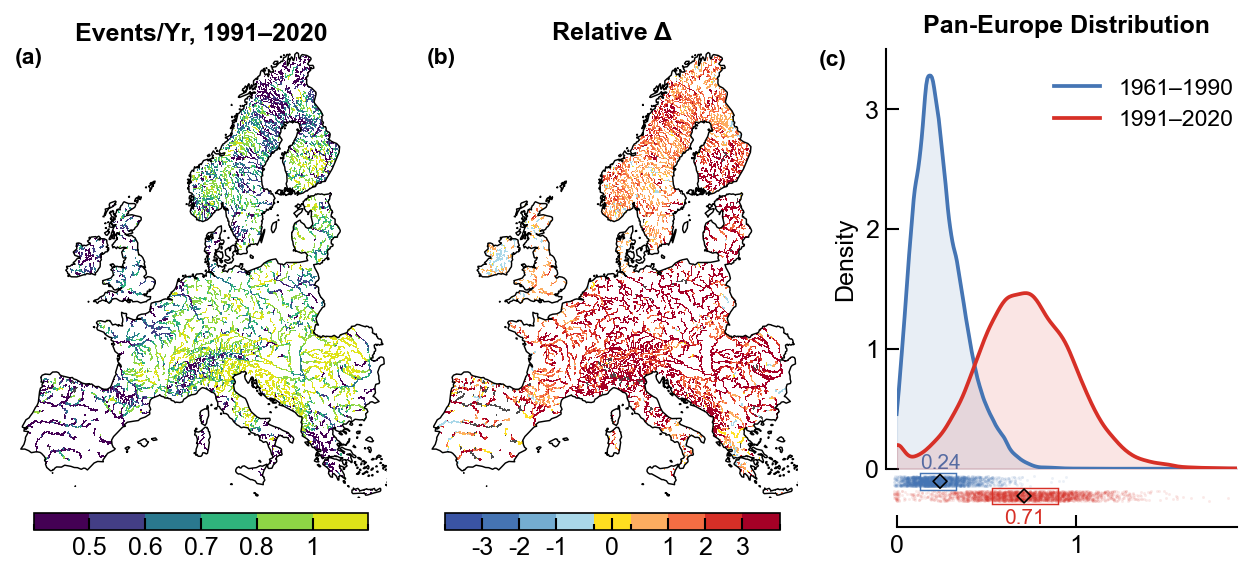

In [44]:
# Create map features adder
add_map_features = create_map_features_adder()

# Example: Save the figure
fig = plot_three_panel_analysis(
    data_1961to1990=CE_Q10_TX90_1961to1990_FD,
    data_1991to2020=CE_Q10_TX90_1991to2020_FD,
    variable_name='mean_annual_frequency',
    cmap_sequential= viridis_mod,
    extend_colorbar = 'both',
    bins_map=[0.5, 0.6, 0.7, 0.8, 1],#[0.5, 0.6, 0.7, 0.8, 0.9], #np.arange(0.25, 1.4, 0.25),
    bins_delta=np.array([-3, -2, -1, -0.025, 0.025, 1, 2, 3]),
    yellow_range=(-0.025, 0.025),
    kde_ylim=(0, 3.5),
    kde_xlim=(0, 1.9),
    kde_yticks=(0, 1, 2, 3),
    #kde_position_adjust=(0.05, -0.078, 0.00, 0.01), #(x_offset, y_offset, w_offset, h_offset) to adjust KDE panel position
    tick_positions_delta=[-3, -2, -1, 0, 1, 2, 3],
    #filename='Fig1_abc',  # Save with this name
    save_formats=['pdf'],
    dpi=300,
    titles = {
            'panel1': 'Events/Yr, 1991\u20132020',
            'panel2': 'Relative Δ', #"Relative \u0394 (91-20 vs 61-90)"
            'panel3': 'Pan-Europe Distribution'
        },
    tick_interval=1,
    title_fontsize=12,
    cbar_tick_fontsize=12,
    add_map_features_func=add_map_features,
    verbose=False,
)
#plt.show()
#plt.close()

## Fig1_def

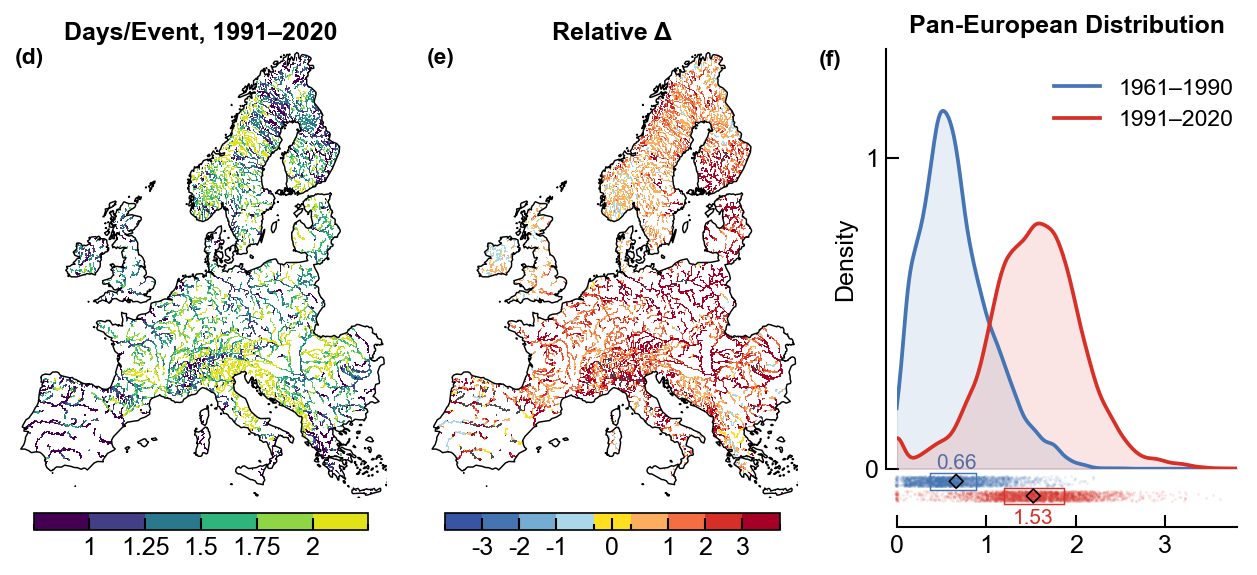

In [46]:
# Create map features adder
add_map_features = create_map_features_adder()

# Example: Save the figure
fig = plot_three_panel_analysis(
    data_1961to1990=convert_timedelta_var(CE_Q10_TX90_1961to1990_FD, 'mean_annual_duration'),
    data_1991to2020=convert_timedelta_var(CE_Q10_TX90_1991to2020_FD, 'mean_annual_duration'),
    variable_name='mean_annual_duration',
    cmap_sequential= viridis_mod,
    bins_map=[1, 1.25, 1.5, 1.75, 2.0],#np.arange(0.5, 3.0, 0.5),
    extend_colorbar='both',
    bins_delta=np.array([-3, -2, -1, -0.025, 0.025, 1, 2, 3]),
    yellow_range=(-0.025, 0.025),
    kde_ylim=(0, 1.35),
    kde_yticks=(0, 1.0),
    kde_xlim=(0, 3.8),
    tick_positions_delta=[-3, -2, -1, 0, 1, 2, 3],
    #filename='Fig1_def',  # Save with this name
    panel_labels = ['d', 'e', 'f'],
    save_formats=['pdf'],
    dpi=300,
    titles = {
            'panel1': 'Days/Event, 1991\u20132020',
            'panel2': 'Relative \u0394',#"Relative \u0394 (91-20 vs 61-90)"
            'panel3': 'Pan-European Distribution'
        },
    tick_interval=1,
    title_fontsize=12,
    cbar_tick_fontsize=12,
    add_map_features_func=add_map_features,
    verbose=False,
)
#plt.show()
#plt.close()

## Fig1_g

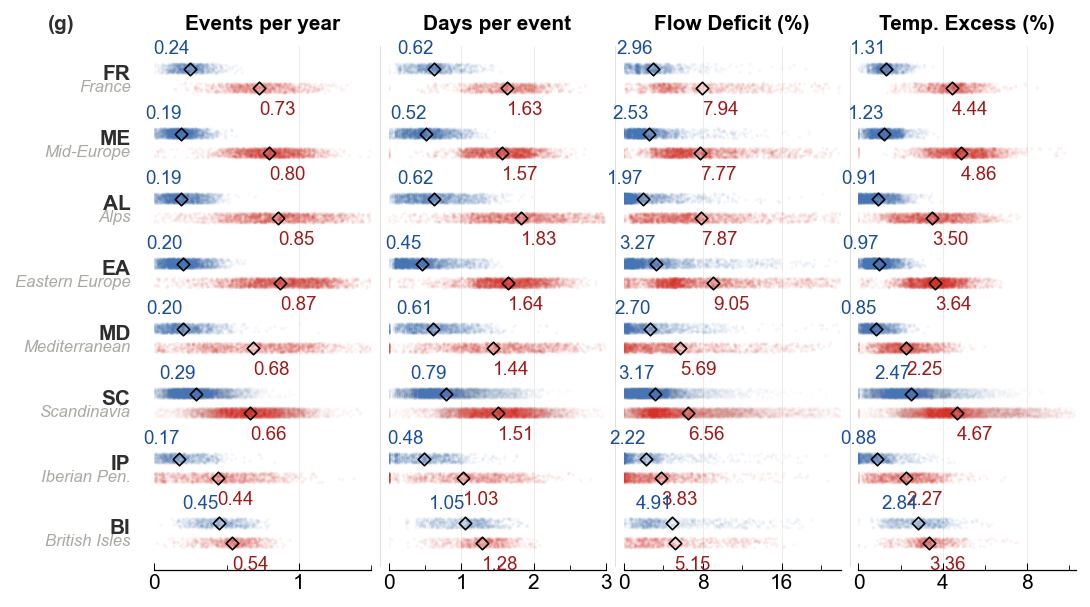

In [40]:
# four separate stat dicts, one per column
stats_ce_freq = compute_region_stats(
    data_old     = CE_Q10_TX90_1961to1990_FD,
    data_new     = CE_Q10_TX90_1991to2020_FD,
    region_mask  = europe_PRUDENCE_regions,
    var_name     = 'mean_annual_frequency',
)
stats_ce_dur = compute_region_stats(
    data_old     = convert_timedelta_var(CE_Q10_TX90_1961to1990_FD, 'mean_annual_duration'),
    data_new     = convert_timedelta_var(CE_Q10_TX90_1991to2020_FD, 'mean_annual_duration'),
    region_mask  = europe_PRUDENCE_regions,
    var_name     = 'mean_annual_duration',
)
stats_ce_lowflwdef = compute_region_stats(
    data_old     = CE_Q10_TX90_1961to1990_Intensity,
    data_new     = CE_Q10_TX90_1991to2020_Intensity,
    region_mask  = europe_PRUDENCE_regions,
    var_name     = 'mean_annual_flow_intensity_scaled',
)
stats_ce_temExs = compute_region_stats(
    data_old     = CE_Q10_TX90_1961to1990_Intensity,
    data_new     = CE_Q10_TX90_1991to2020_Intensity,
    region_mask  = europe_PRUDENCE_regions,
    var_name     = 'mean_annual_temperature_intensity_scaled',
)


columns_def = [
    dict(
        stats      = stats_ce_freq,
        title      = 'Events per year',
        xlabel     = 'Events per year',
        xmin       = 0.0,  xmax = 1.5,
        major_tick = 1.0,
        h_jitter   = 0.05,  
    ),
    dict(
        stats      = stats_ce_dur,
        title      = 'Days per event',
        xlabel     = 'Days per event',
        xmin       = 0.0,  xmax = 3,
        major_tick = 1.0,
        h_jitter   = 0.0,  
    ),
    dict(
        stats      = stats_ce_lowflwdef,
        title      = 'Flow Deficit (%)',
        xlabel     = 'Flow Deficit (%)',
        xmin       = 0.0,  xmax = 22,
        major_tick = 8.0,
        h_jitter   = 0.0, 
    ),
    dict(
        stats      = stats_ce_temExs,
        title      = 'Temp. Excess (%)',
        xlabel     = 'Temp. Excess (%)',
        xmin       = 0.0,  xmax = 10.3,
        major_tick = 4.0,
        h_jitter   = 0.0,  
    ),
]

# reorder by simply changing the list order
# e.g. swap frequency and duration:
# columns_def = [columns_def[2], columns_def[3], columns_def[0], columns_def[1]]

# unpack and plot
fig = plot_strip_8x4(
    **{f'stats_col{i+1}':      c['stats']                for i, c in enumerate(columns_def)},
    **{f'col{i+1}_title':      c['title']                for i, c in enumerate(columns_def)},
    **{f'col{i+1}_xlabel':     c['xlabel']               for i, c in enumerate(columns_def)},
    **{f'xmin_col{i+1}':       c['xmin']                 for i, c in enumerate(columns_def)},
    **{f'xmax_col{i+1}':       c['xmax']                 for i, c in enumerate(columns_def)},
    **{f'major_tick_col{i+1}': c['major_tick']           for i, c in enumerate(columns_def)},
    **{f'h_jitter_col{i+1}':   c.get('h_jitter', 0.0)   for i, c in enumerate(columns_def)},
    dot_stat     = 'mean',    
    jitter_frac  = 0.50,      
    col_header_fs=10,
    annot_fs=9,
    row_height_mm=11,
    region_alpha = {
    'FR': 0.05, 'ME': 0.05, 'AL': 0.05, 'EA': 0.05,
    'MD': 0.05, 'SC': 0.015, 'IP': 0.05, 'BI': 0.05,
},
    panel_label  = '(g)',
    #filename    = 'Fig1_g_strip_8x4',
    save_formats = ['pdf'],
)

# Fig-2

In [47]:
load_dir = DATA_DIR + '/'
CE_Q10_TX90_1991to2020_attribution_xr  = xr.open_dataset(load_dir + 'CE_Q10_TX90_1991to2020_lmdi_attribution.nc')


data_regional_lmdi= np.load(
    os.path.join(DATA_DIR, 'CE_Q10_TX90_1991to2020_regional_attribution_arrays.npz'),
    allow_pickle=True   # needed for string arrays
)

N_means   = data_regional_lmdi['N_means']
D_means   = data_regional_lmdi['D_means']
R_means   = data_regional_lmdi['R_means']
N_stds    = data_regional_lmdi['N_stds']
D_stds    = data_regional_lmdi['D_stds']
R_stds    = data_regional_lmdi['R_stds']
ce_changes          = data_regional_lmdi['ce_changes']
grid_counts_sorted  = data_regional_lmdi['grid_counts'].tolist()
sort_indices        = data_regional_lmdi['sort_indices']
region_names_sorted      = data_regional_lmdi['region_names_short'].tolist()
region_names_full_sorted = data_regional_lmdi['region_names_full'].tolist()

sh: getfattr: command not found


## Fig2_abc

Colors: 13 | Blue: 2 | Yellow: 1 | Red: 8


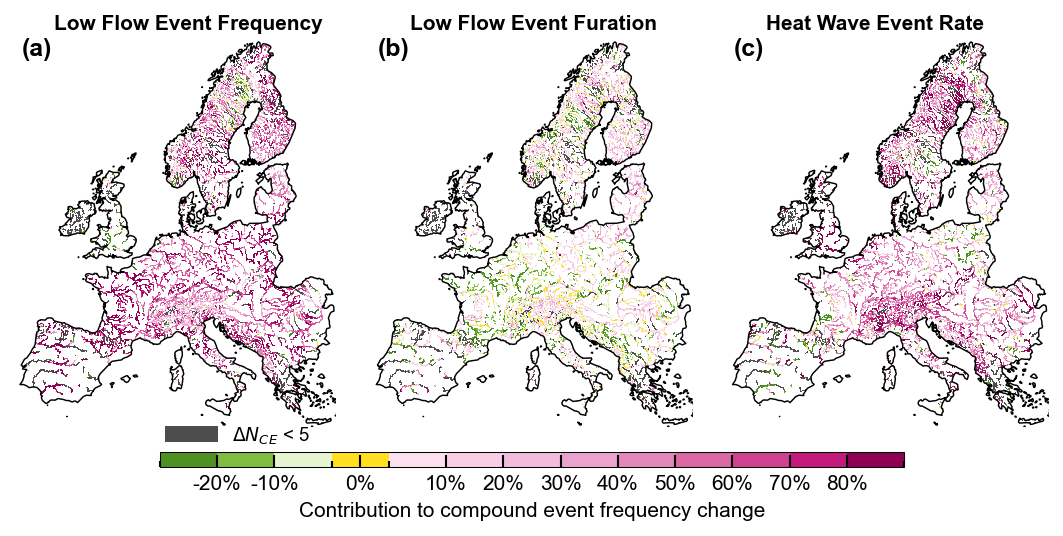

✓ Saved: /work/ch0636/g300138/LowFlowHeatWave/CompoundLowFlowHeatWave/Figure/Fig2_abc.pdf


In [48]:
def plot_lmdi_attribution_map(
    attribution_xr, 
    figwidth=7.09,
    cbar_ticks=None,
    show_stats=False,
    show_panel_labels=True,
    colorbar_label='Contribution to CE change (%)',
    titles=None,
    subplot_spacing=0.05
):
    """
    Create a 3-panel map showing LMDI attribution percentages.
    
    Parameters:
    -----------
    attribution_xr : xarray.Dataset
        Dataset containing lmdi_N_percentage, lmdi_D_percentage, lmdi_R_percentage
    vmin, vmax : float
        Min and max values for colorbar
    figwidth : float
        Figure width in inches (default: 7.09 for Nature double column)
    cbar_ticks : list or array, optional
        Custom colorbar tick locations
    show_stats : bool
        Show statistics box in each panel
    show_panel_labels : bool
        Show (a), (b), (c) labels
    colorbar_label : str
        Label for colorbar
    titles : list of str, optional
        Custom titles for each panel
    subplot_spacing : float
        Space between subplots (default: 0.05)
    
    Returns:
    --------
    fig, axes
    """
    
    # Create custom colormap
    
    # User-defined bins
    bins = np.array([-20, -10, -2, 2, 10, 20, 30, 40, 50, 60, 70, 80])
    yellow_range = (-2, 2)  # Middle range for yellow
    
    # Create boundaries
    boundaries = np.concatenate((
    np.array([-99998]),  # Just above -99999
    bins, 
    np.array([1e6])
))

    n_colors = len(boundaries) - 1
    
    # Automatically calculate color sections
    negative_bins = bins[bins < yellow_range[0]]
    positive_bins = bins[bins > yellow_range[1]]
    
    n_extreme_low = 1
    n_blue = len(negative_bins)
    n_yellow = 1
    n_red = len(positive_bins)
    n_extreme_high = 1
    
    print(f"Colors: {n_colors} | Blue: {n_blue} | Yellow: {n_yellow} | Red: {n_red}")
    
    # Get colormap
    RdYlBu_or = plt.cm.PiYG
    
    # Create color sections
    extreme_blue = RdYlBu_or(np.linspace(0.90, 1.0, n_extreme_low))      # Darkest blue (extreme negative)
    blue_colors = RdYlBu_or(np.linspace(0.80, 0.60, n_blue))             # Blue shades (negative values)
    gold_color = '#FFDF20'
    yellow_colors = np.tile(to_rgba(gold_color), (n_yellow, 1))         # Yellow center
    red_colors = RdYlBu_or(np.linspace(0.40, 0.10, n_red))               # Red shades (positive values)
    extreme_red = RdYlBu_or(np.linspace(0.0, 0.05, n_extreme_high))      # Darkest red (extreme positive)
    
    # Combine all sections (ORDER: blue, yellow, red - from left to right)
    colors = np.vstack([extreme_blue, blue_colors, yellow_colors, red_colors, extreme_red])
    RdYlBu_mod = ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries, n_colors)

    # Set gray for values below threshold
    RdYlBu_mod.set_under(color='#4D4D4D')
    
    # Create map
    
    # Map projection
    projection = ccrs.LambertConformal(
        central_latitude=53,
        central_longitude=12,
        standard_parallels=(45, 65)
    )
    
    # Calculate figure height
    figheight = figwidth * 0.4
    
    # Create figure and GridSpec
    fig = plt.figure(figsize=(figwidth, figheight))
    
    gs = GridSpec(
        1, 3, 
        figure=fig, 
        left=0.02, 
        right=0.98, 
        top=0.92, 
        bottom=0.20,
        wspace=subplot_spacing, 
        hspace=0
    )
    
    # Create axes with projection
    axes = [fig.add_subplot(gs[0, i], projection=projection) for i in range(3)]
    
    # Default titles
    if titles is None:
        titles = [
            "Low Flow Event Frequency",
            "Low Flow Event Furation",
            "Heat Wave Event Rate"
        ]
    
    datasets = [
        (attribution_xr.lmdi_N_percentage, titles[0]),
        (attribution_xr.lmdi_D_percentage, titles[1]),
        (attribution_xr.lmdi_R_percentage, titles[2])
    ]
    
    # Plot each panel
    for i, (ax, (da, title)) in enumerate(zip(axes, datasets)):
        # Add map features
        add_map_features(ax)
        
        # Plot data
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=RdYlBu_mod,
            norm=norm,
            add_colorbar=False,
            zorder=2,
            rasterized=True,
        **{'antialiased': False, 'edgecolors': 'none', 'linewidth': 0}
        )

        set_axis_linewidth(ax, linewidth=0.0)
        
        # Set title
        #ax.set_title(title, fontsize=10, fontweight='bold', pad=5)
        # Set title - manually positioned to match panel label height
        ax.text(
            0.12, 1.06,          # Same y=1.06 as panel label; x offset to clear the label
            title,
            transform=ax.transAxes,
            fontsize=10,
            fontweight='bold',
            va='top',
            ha='left',
        )
        
        # Calculate and display statistics
        if show_stats:
            data_valid = da.values[da.values != -9999]
            if len(data_valid) > 0:
                median_val = np.nanmedian(data_valid)
                q25 = np.nanpercentile(data_valid, 25)
                q75 = np.nanpercentile(data_valid, 75)
                
                ax.text(
                    0.02, 0.98,
                    f"Median: {median_val:.1f}%\n"
                    f"IQR: [{q25:.1f}, {q75:.1f}]",
                    transform=ax.transAxes,
                    fontsize=7.5,
                    va='top', ha='left',
                    bbox=dict(
                        boxstyle='round,pad=0.3',
                        facecolor='white',
                        alpha=0.9,
                        edgecolor='0.3',
                        linewidth=0.5
                    )
                )
        
        # NATURE-STYLE PANEL LABELS (a), (b), (c)
        if show_panel_labels:
            panel_labels = ['a', 'b', 'c']
            
            # Position: Top-left corner inside the panel
            ax.text(
                0.02, 1.0,  # Position in axes coordinates
                f'({panel_labels[i]})',
                transform=ax.transAxes,
                fontsize=12,
                fontweight='bold',
                va='top',
                ha='left',
                # bbox=dict(
                #     boxstyle='round,pad=0.4',
                #     facecolor='white',
                #     edgecolor='black',
                #     linewidth=1.0,
                #     alpha=0.9
                # ),
                zorder=100  # Ensure it's on top
            )
    
    # Create colorbar
    
    # Create colorbar axis
    cbar_ax = fig.add_axes([0.15, -0.08, 0.7, 0.035])
    
    # Determine colorbar ticks
    if cbar_ticks is None:
        cbar_ticks = np.arange(-20, 90, 10)
    
    # Create colorbar
    cbar = fig.colorbar(
        im,
        cax=cbar_ax,
        orientation='horizontal',
        ticks=cbar_ticks,
        boundaries=boundaries,
        extend='neither'
    )
    
    cbar.set_label(colorbar_label, fontsize=10, fontweight='normal')
    cbar.ax.tick_params(labelsize=10)
    # Without Percentage Sign
    #cbar.ax.set_xticklabels([f'{x:.0f}' for x in cbar_ticks])
    # With Percentage Sign
    cbar.ax.set_xticklabels([f'{x:.0f}%' for x in cbar_ticks])

    # GRAY PATCH LEGEND: Delta CE < 5
    
    # Position the patch just to the left of the colorbar
    # cbar_ax is at [0.15, -0.08, 0.7, 0.035] in figure coordinates
    patch_x = 0.205        # right edge just touching colorbar left (0.15)
    patch_y = -0.02     # vertically centered on colorbar
    patch_w = 0.05
    patch_h = 0.038

    gray_patch = mpatches.FancyBboxPatch(
        (patch_x - patch_w, patch_y),
        patch_w, patch_h,
        boxstyle="square,pad=0",
        facecolor='#4D4D4D',
        edgecolor='none',
        transform=fig.transFigure,
        clip_on=False,
        zorder=10
    )
    fig.add_artist(gray_patch)

    fig.text(
        patch_x + 0.05,     # horizontally centered on the patch
        patch_y + (patch_h / 2 -0.004),     # vertically centered on the patch
        r'$\Delta N_{CE}$ < 5',
        ha='center',
        va='center',
        fontsize=9,
        color='black',
        fontweight='normal',
        zorder=11
    )
    
    return fig, axes


# Usage

fig, axes = plot_lmdi_attribution_map(
    CE_Q10_TX90_1991to2020_attribution_xr,
    figwidth=7.09,
    cbar_ticks=np.arange(-20, 90, 10),
    colorbar_label='Contribution to compound event frequency change',
    subplot_spacing=0.05,
    show_stats=False,
    show_panel_labels=True
)
plt.show()

# Save figure
#filename = 'Fig2_abc'  # Set your desired filename
save_formats = ['pdf']  # Set your desired formats
dpi = 300  # Set your desired DPI

save_dir = FIGURE_DIR
os.makedirs(save_dir, exist_ok=True)

for fmt in save_formats:
    filepath = os.path.join(save_dir, f'{filename}.{fmt}')
    if fmt.lower() in ['jpg', 'jpeg', 'png', 'tiff']:
        fig.savefig(filepath, dpi=dpi, format=fmt, bbox_inches='tight')
    else:
        fig.savefig(filepath, format=fmt, bbox_inches='tight')
    print(f"✓ Saved: {filepath}")

plt.close(fig)

## Fig 2b

✓ Saved: /work/ch0636/g300138/LowFlowHeatWave/CompoundLowFlowHeatWave/Figure/Fig2_abc.pdf


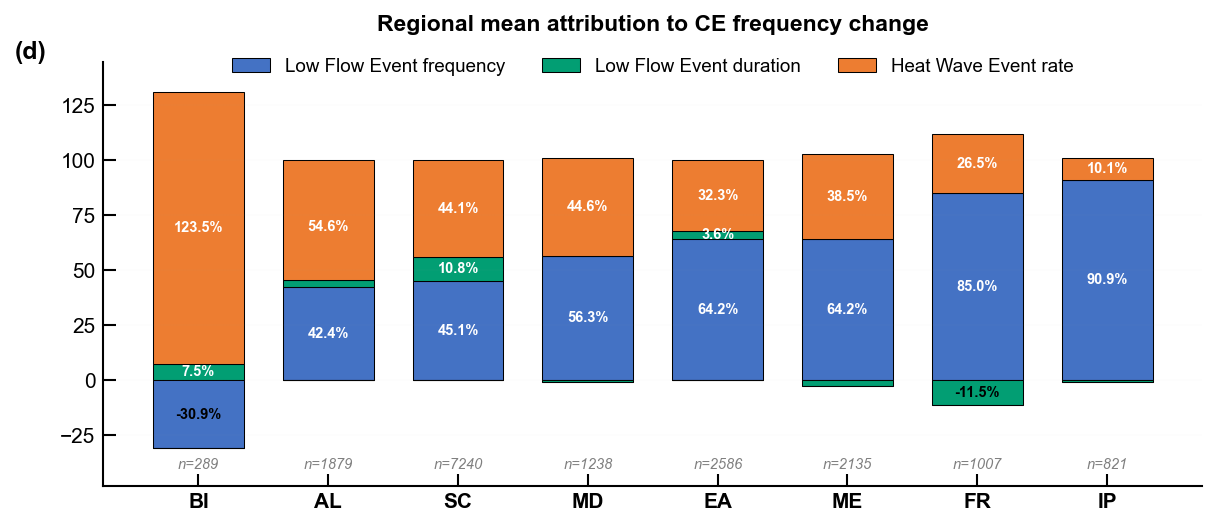

In [49]:
colors = {
    "N": "#4472C4",  # Blue
    "D": "#029E73",  # #A5A5A5Gray, #029E73 Teal
    "R": "#ED7D31"   # Orange
}


region_names_sorted = data_regional_lmdi['region_names_short'].tolist()

# Create stacked bar chart

fig, ax = plt.subplots(figsize=(8, 3.4))

x = np.arange(len(region_names_sorted))
bar_width = 0.7

# Separate positive and negative parts
N_pos = np.where(N_means > 0, N_means, 0)
D_pos = np.where(D_means > 0, D_means, 0)
R_pos = np.where(R_means > 0, R_means, 0)

N_neg = np.where(N_means < 0, N_means, 0)
D_neg = np.where(D_means < 0, D_means, 0)
R_neg = np.where(R_means < 0, R_means, 0)

# Positive stacking
bar1_pos = ax.bar(x, N_pos, bar_width, color=colors["N"], 
                  label="Low Flow Event frequency", edgecolor='black', linewidth=0.5)
bar2_pos = ax.bar(x, D_pos, bar_width, bottom=N_pos, color=colors["D"], 
                  label="Low Flow Event duration", edgecolor='black', linewidth=0.5)
bar3_pos = ax.bar(x, R_pos, bar_width, bottom=N_pos + D_pos, color=colors["R"], 
                  label="Heat Wave Event rate", edgecolor='black', linewidth=0.5)

# Negative stacking
bar1_neg = ax.bar(x, N_neg, bar_width, color=colors["N"], 
                  edgecolor='black', linewidth=0.5)
bar2_neg = ax.bar(x, D_neg, bar_width, bottom=N_neg, color=colors["D"], 
                  edgecolor='black', linewidth=0.5)
bar3_neg = ax.bar(x, R_neg, bar_width, bottom=N_neg + D_neg, color=colors["R"], 
                  edgecolor='black', linewidth=0.5)

# Calculate standard error (SE = std / sqrt(n))
N_se = N_stds / np.sqrt(grid_counts_sorted)
D_se = D_stds / np.sqrt(grid_counts_sorted)
R_se = R_stds / np.sqrt(grid_counts_sorted)

# # Total error (approximate - assumes independence)
total_se = np.sqrt(N_se**2 + D_se**2 + R_se**2)
total_mean = N_means + D_means + R_means

# Annotate with values and CE changes

# Annotate stacked bars with percentages
for i in range(len(region_names_sorted)):
    # Positive stacks
    y_offset = 0
    for val in [N_means[i], D_means[i], R_means[i]]:
        if val > 0 and abs(val) > 3:  # Only show if > 3% (avoid clutter)
            ax.text(
                x[i], y_offset + val / 2,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=7, color="white", fontweight='bold'
            )
            y_offset += val

    # Negative stacks
    y_offset = 0
    for val in [N_means[i], D_means[i], R_means[i]]:
        if val < 0 and abs(val) > 3:
            ax.text(
                x[i], y_offset + val / 2,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=7, color="black", fontweight='bold'
            )
            y_offset += val

# Add grid counts below x-axis

for i in range(len(region_names_sorted)):
    ax.text(
        x[i], -35,  # Position below x-axis
        f"n={grid_counts_sorted[i]}",
        ha="center", va="top",
        fontsize=7, color="gray", style='italic'
    )

# Formatting

# Zero line
ax.axhline(0, color="black", linewidth=0, zorder=5)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(region_names_sorted, fontsize=10, fontweight='bold')
#ax.set_ylabel("Attribution to CE change (%)", fontsize=11, fontweight='bold')

# Set y-axis limits to accommodate annotations
ax.set_ylim(-48, max(total_mean + total_se) + 40)

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.1, zorder=0)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

# Ticks
ax.tick_params(axis="both", labelsize=10, width=1)

ax.legend(
    frameon=False, fontsize=9, loc="upper center",
    ncols=3, framealpha=0.9, edgecolor='black',
    bbox_to_anchor=(0.5, 1.05)  # ← increase second value to move up
)

# Add panel label
ax.text(
    -0.08, 1.05, '(d)',
    transform=ax.transAxes,
    fontsize=12, fontweight='bold',
    va='top', ha='left'
)

# Title
ax.set_title(
    'Regional mean attribution to CE frequency change',
    fontsize=11, fontweight='bold', pad=15
)

# Save figure

#filename = 'Fig2_d'
save_formats = ['pdf']
dpi = 300

save_dir = FIGURE_DIR
os.makedirs(save_dir, exist_ok=True)

for fmt in save_formats:
    filepath = os.path.join(save_dir, f'{filename}.{fmt}')
    if fmt.lower() in ['jpg', 'jpeg', 'png', 'tiff']:
        fig.savefig(filepath, dpi=dpi, format=fmt, bbox_inches='tight')
    else:
        fig.savefig(filepath, format=fmt, bbox_inches='tight')
    print(f"✓ Saved: {filepath}")

plt.show()


# Fig3

In [50]:
load_dir = DATA_DIR + '/'

CE_Q10_TX90_1991to2020_ceperhwe_ceperlfe_day  = xr.open_dataset(load_dir + 'CE_Q10_TX90_1991to2020_annualmean_ceperhwe_ceperlfe_day.nc')
CE_Q10_TX90_1961to1990_ceperhwe_ceperlfe_day  = xr.open_dataset(load_dir + 'CE_Q10_TX90_1961to1990_annualmean_ceperhwe_ceperlfe_day.nc')
CEperHWE_CEperLFE_annual_tms = pd.read_parquet(load_dir + 'CEperHWE_CEperLFE_annual_tms.parquet')

sh: getfattr: command not found
sh: getfattr: command not found


In [51]:
CE_Q10_TX90_1991to2020_attribution_xr = xr.open_dataset(
    os.path.join(DATA_DIR, 'CE_Q10_TX90_1991to2020_lmdi_attribution.nc')
)

sh: getfattr: command not found


## Fig3_abcd

In [53]:
fig=plot_four_panel_analysis(
    data_past_1=CE_Q10_TX90_1961to1990_ceperhwe_ceperlfe_day,
    data_present_1=CE_Q10_TX90_1991to2020_ceperhwe_ceperlfe_day,
    data_past_2=CE_Q10_TX90_1961to1990_ceperhwe_ceperlfe_day,
    data_present_2=CE_Q10_TX90_1991to2020_ceperhwe_ceperlfe_day,
    variable_name_1='ce_per_lfe_days',
    variable_name_2='ce_per_hwe_days',
    bins_map_1=[0.1, 0.15, 0.20, 0.25, 0.30],#[0.1, 0.15, 0.20, 0.25, 0.30]
    bins_map_2=[0.1, 0.15, 0.20, 0.25, 0.30],#[0.1, 0.15, 0.20, 0.25, 0.30],
    bins_delta=np.array([-2, -1, -0.5, -0.025, 0.025, 0.5, 1, 2]),
    yellow_range=(-0.025, 0.025),
    use_nondefault_cmap=True,
    cmap_sequential_1=viridis_mod,
    cmap_sequential_2=viridis_mod,
    cmap_sequential_range=(0.05,0.9),
    extend_colorbar_1='both',
    extend_colorbar_2='both',
    tick_positions_delta=[-2, -1, -0.5, 0,  0.5, 1, 2],
    titles={
        'panel1': r'$\mathrm{HWR}_{\mathrm{LF}}$, 1991-2020',
        'panel2': 'Relative \u0394', #"Relative \u0394 (91-20 vs 61-90)"
        'panel3': r'$\mathrm{LFR}_{\mathrm{HW}}$, 1991-2020',
        'panel4': 'Relative \u0394', #"Relative \u0394 (91-20 vs 61-90)"
    },
    #filename='Fig3_abcd',
    save_formats=['pdf'],
    dpi=300,
    figsize=(180, 75),  # mm (width, height)
    title_fontsize=11,
    cbar_tick_fontsize=9,
    tick_interval_1=1,
    tick_interval_2=1,
    add_map_features_func=add_map_features,
)
#plt.show()
#plt.close()

✓ Saved: /work/ch0636/g300138/LowFlowHeatWave/CompoundLowFlowHeatWave/Figure/Fig3_abcd.pdf


## Fig3_e

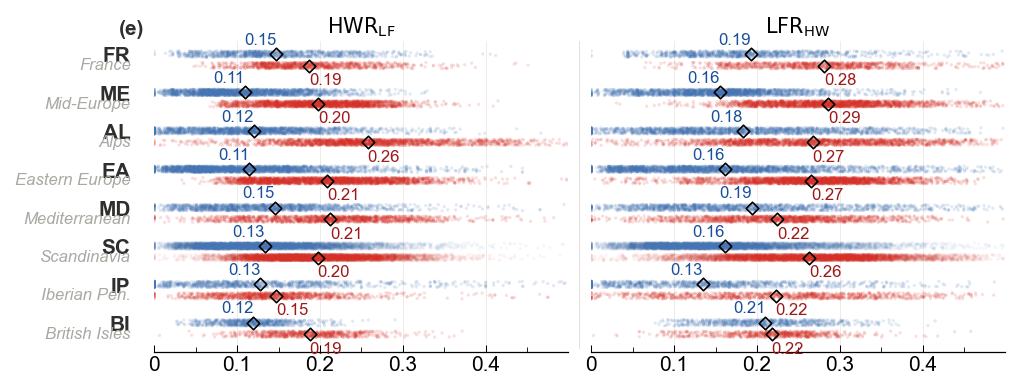

✓  Saved: /work/ch0636/g300138/LowFlowHeatWave/CompoundLowFlowHeatWave/Figure/Fig3_e.pdf


In [54]:
# four separate stat dicts, one per column
stats_ce_per_lfe = compute_region_stats(
    data_old=CE_Q10_TX90_1961to1990_ceperhwe_ceperlfe_day,
    data_new=CE_Q10_TX90_1991to2020_ceperhwe_ceperlfe_day,
    region_mask=europe_PRUDENCE_regions,
    var_name='ce_per_lfe_days',
)

stats_ce_per_hwe = compute_region_stats(
    data_old=CE_Q10_TX90_1961to1990_ceperhwe_ceperlfe_day,
    data_new=CE_Q10_TX90_1991to2020_ceperhwe_ceperlfe_day,
    region_mask=europe_PRUDENCE_regions,
    var_name='ce_per_hwe_days',
)

fig = plot_strip_8x2(
    stats_lfe    = stats_ce_per_lfe,
    stats_hwe    = stats_ce_per_hwe,
    # centre statistic
    dot_stat     = 'mean',
    # column titles
    lfe_title    = r'$\mathrm{HWR}_{\mathrm{LF}}$',
    hwe_title    = r'$\mathrm{LFR}_{\mathrm{HW}}$',
    # x-axis limits
    xmin_lfe=0.0, xmax_lfe=0.499,
    xmin_hwe=0.0, xmax_hwe=0.499,
    # major tick interval
    major_tick_lfe=0.1,
    major_tick_hwe=0.1,
    # layout
    figwidth_mm   = 180,
    row_height_mm = 6.5,
    # strip appearance
    alpha        = 0.15,
    # font sizes
    col_header_fs = 10.0,
    tick_fs       = 10.0,
    annot_fs      = 8,
    region_alpha = {     
        'SC': 0.05, 
    },
    # labels
    panel_label   = '(e)',
    # save
    save_dir      = FIGURE_DIR,
    #filename      = 'Fig3_e',
    save_formats  = None,
    dpi           = 300,
)

## Fig3_f

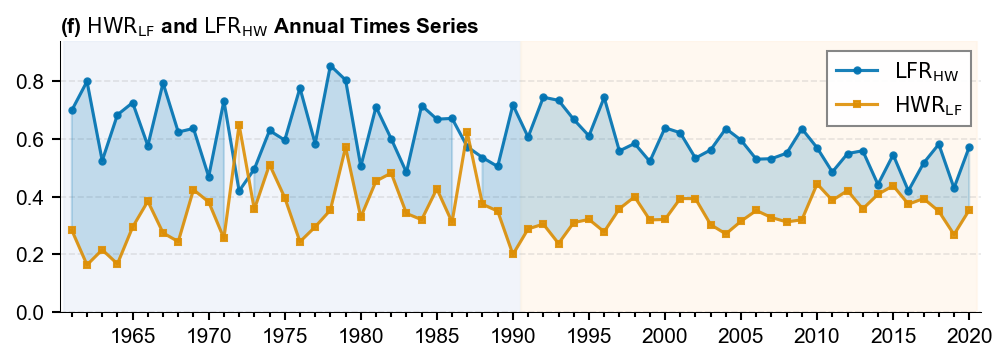

In [55]:
def plot_compound_events_coupling(
    df,
    year_col='year',
    hwe_fraction_col='mean_ce_per_hwe_days_active',
    lfe_fraction_col='mean_ce_per_lfe_days_active',
    savename=None,
    save_dir: str      = FIGURE_DIR,
    color_water_vuln='#0173B2',  # Blue
    color_river_heat='#DE8F05',  # Orange
    color_period1='#E8EEF7',  # Cool gray-blue for 1961-1990
    color_period2='#FFF4E6',  # Warm cream for 1991-2020
    show_legend_box=True,
    marker_size=3,
    period_split_year=1990,
    plot_type='area'  # 'grouped' or 'area'
):
    """
    Create figure showing compound event coupling metrics.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the data
    year_col : str
        Name of the year column
    hwe_fraction_col : str
        Column for Water Vulnerability (CE/HWE)
    lfe_fraction_col : str
        Column for River Heat Stress (CE/LFE)
    savename : str, optional
        Base name for saving figure
    save_dir : str, optional
        Directory to save figures
    color_water_vuln : str
        Color for Water Vulnerability (CE/HWE)
    color_river_heat : str
        Color for River Heat Stress (CE/LFE)
    color_period1 : str
        Background color for 1961-1990 period
    color_period2 : str
        Background color for 1991-2020 period
    show_legend_box : bool
        Whether to show box around legend
    marker_size : float
        Size of markers on line plots
    period_split_year : int
        Year dividing the two periods (default: 1990)
    plot_type : str
        'grouped' for grouped bars or 'area' for area plot
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        Matplotlib figure object
    """
    
    # Sort by year
    df = df.sort_values(year_col).copy()
    
    # Extract data
    years = df[year_col].values
    water_vuln = df[hwe_fraction_col].values
    river_heat = df[lfe_fraction_col].values
    
    # Create year labels
    year_labels = [str(int(year)) for year in years]
    x = np.arange(len(year_labels))
    
    # Find period split index
    split_idx = np.where(years <= period_split_year)[0][-1] if any(years <= period_split_year) else len(years)//2
    
    # Create figure
    fig, ax = plt.subplots(figsize=(6.6, 2.30))
    
    # Add period background shading
    ax.axvspan(-0.5, split_idx + 0.5, alpha=0.6, color=color_period1, zorder=0)
    ax.axvspan(split_idx + 0.5, len(years) - 0.5, alpha=0.6, color=color_period2, zorder=0)
    
    if plot_type == 'grouped':
        # Grouped bar chart
        width = 0.35
        x_wv = x - width/2
        x_rh = x + width/2
        
        bars_wv = ax.bar(x_wv, water_vuln, width, 
                         label=r'$\mathrm{LFR}_{\mathrm{HW}}$', 
                         color=color_water_vuln, 
                         edgecolor='white',
                         linewidth=0.5,
                         zorder=3,
                         alpha=0.85)
        
        bars_rh = ax.bar(x_rh, river_heat, width, 
                         label=r'$\mathrm{HWR}_{\mathrm{LF}}$', 
                         color=color_river_heat, 
                         edgecolor='white',
                         linewidth=0.5,
                         zorder=3,
                         alpha=0.85)
        
    else:  # area plot
        # Plot lines
        line_wv = ax.plot(x, water_vuln, color=color_water_vuln, 
                          linewidth=1.5, label=r'$\mathrm{LFR}_{\mathrm{HW}}$',
                          zorder=4, alpha=0.9, marker='o', markersize=marker_size)
        line_rh = ax.plot(x, river_heat, color=color_river_heat, 
                          linewidth=1.5, label=r'$\mathrm{HWR}_{\mathrm{LF}}$',
                          zorder=4, alpha=0.9, marker='s', markersize=marker_size)
        
        # Fill area between (showing asymmetry gap)
        ax.fill_between(x, water_vuln, river_heat, 
                        where=(water_vuln >= river_heat),
                        color=color_water_vuln, alpha=0.2,
                        zorder=2)
        ax.fill_between(x, water_vuln, river_heat, 
                        where=(water_vuln < river_heat),
                        color=color_river_heat, alpha=0.2,
                        zorder=2)
    
    # Create labels and tick positions starting from 1965 at 5-year intervals
    year_values = years.astype(int)
    tick_years = list(range(1965, year_values[-1] + 1, 5))  # 1965, 1970, 1975, ..., 2020
    
    major_tick_positions = []
    major_tick_labels = []
    
    for tick_year in tick_years:
        if tick_year in year_values:
            idx = np.where(year_values == tick_year)[0][0]
            major_tick_positions.append(idx)
            major_tick_labels.append(str(tick_year))
    
    # Set x-ticks with major and minor
    ax.set_xticks(major_tick_positions)
    ax.set_xticks(x, minor=True)
    ax.set_xticklabels(major_tick_labels, rotation=0, ha='center', fontsize=10)
    ax.tick_params(axis='x', which='major', direction='out', length=4, width=1)
    ax.tick_params(axis='x', which='minor', direction='out', length=2.5, width=1)
    
    ax.tick_params(axis='y', labelsize=10, width=1, length=4, direction='out')
    
    max_coupling = max(np.max(water_vuln), np.max(river_heat)) if len(water_vuln) > 0 else 1
    ax.set_ylim(0, max_coupling * 1.10 if max_coupling > 0 else 1)
    ax.set_xlim(-0.8, len(years) - 0.2)
    #ax.set_ylabel('Coupling Fraction', fontsize=10, fontweight='normal')
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legend
    ax.legend(loc='upper right', frameon=show_legend_box, 
              fontsize=10, framealpha=0.95, edgecolor='gray', fancybox=False)
    
    # Title - Updated
    ax.set_title(r'(f) $\mathrm{HWR}_{\mathrm{LF}}$ and $\mathrm{LFR}_{\mathrm{HW}}$ Annual Times Series',
                 fontsize=10, fontweight='bold', loc='left')
    
    #plt.tight_layout()
    
    # Save figure
    if savename and save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, f'{savename}.pdf'), 
                   format='pdf', bbox_inches='tight', dpi=300)
        print(f"✓ Figure saved: {savename}")
        plt.close(fig)
    
    return fig

# Plot 2: Coupling Metrics (area plot)
fig2 = plot_compound_events_coupling(
    CEperHWE_CEperLFE_annual_tms,
    #savename='Fig3_f',
    plot_type='area'
)
plt.show()

# Fig-4

### Fig4a

In [56]:
base_path = DATA_DIR + '/'

ranked_years_df = pd.read_csv(os.path.join(base_path, 'Fig4_Intensity_extent_scatter_data.csv'))

# print(f"✓ Loaded: {ranked_years_df.shape}")
# print(ranked_years_df.head())

✓ Saved


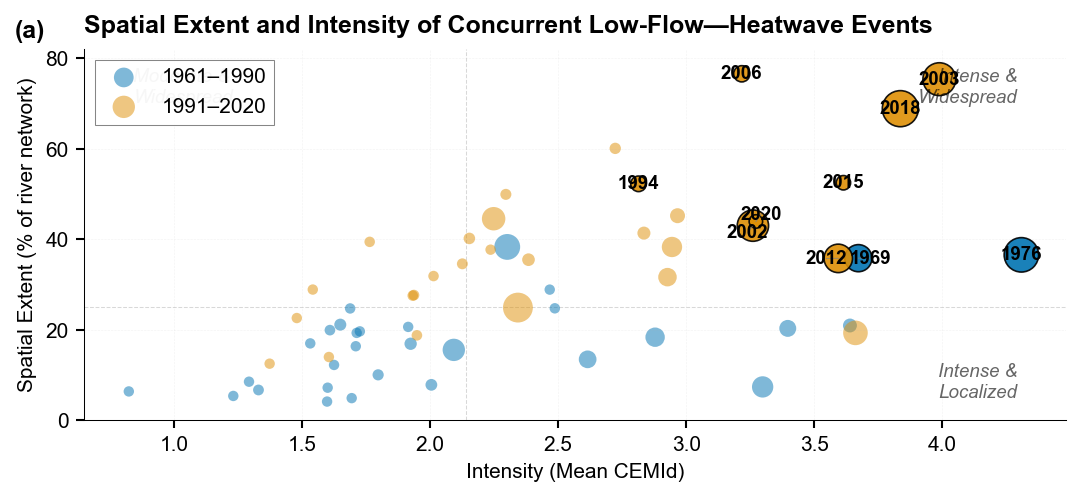

In [57]:
def scale_marker_sizes(values, min_size=25, max_size=300, power=6.0):
    values = np.asarray(values, dtype=float)
    order = np.argsort(-values)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(len(values))
    n = len(values)
    pct = 1 - ranks / (n - 1) if n > 1 else np.ones_like(values)
    return min_size + (max_size - min_size) * pct ** power


def repel_text_labels(ax, xs, ys, labels, fontsize=9, fontweight='bold',
                      color='black', iterations=400, force=1.5,
                      connector_color='gray', connector_lw=0.5,
                      move_threshold_px=4):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    orig_disp = ax.transData.transform(np.column_stack([xs, ys]))
    label_pos = orig_disp.copy()

    texts = [ax.text(0, 0, lab, fontsize=fontsize, fontweight=fontweight,
                     color=color, ha='center', va='center', zorder=5)
             for lab in labels]

    def bbox_at(t, pos):
        t.set_position(tuple(ax.transData.inverted().transform(pos)))
        return t.get_window_extent(renderer=renderer)

    for _ in range(iterations):
        bboxes = [bbox_at(t, label_pos[i]) for i, t in enumerate(texts)]
        any_overlap = False
        for i in range(len(texts)):
            for j in range(i + 1, len(texts)):
                bi, bj = bboxes[i], bboxes[j]
                if bi.overlaps(bj):
                    any_overlap = True
                    ci = np.array([bi.x0 + bi.width / 2, bi.y0 + bi.height / 2])
                    cj = np.array([bj.x0 + bj.width / 2, bj.y0 + bj.height / 2])
                    delta = ci - cj
                    if np.linalg.norm(delta) < 1e-6:
                        delta = np.random.default_rng(i * 1000 + j).uniform(-1, 1, size=2)
                    delta = delta / (np.linalg.norm(delta) + 1e-9)
                    label_pos[i] += delta * force
                    label_pos[j] -= delta * force
        if not any_overlap:
            break

    final_data_pos = ax.transData.inverted().transform(label_pos)
    for i, t in enumerate(texts):
        t.set_position(tuple(final_data_pos[i]))
        if np.linalg.norm(label_pos[i] - orig_disp[i]) > move_threshold_px:
            ax.plot([xs[i], final_data_pos[i][0]], [ys[i], final_data_pos[i][1]],
                    color=connector_color, linewidth=connector_lw, zorder=3, alpha=0.7)
    return texts


# LOAD DATA
base_path = DATA_DIR + '/'
ranked_years_df = pd.read_csv(os.path.join(base_path, 'Fig4_Intensity_extent_scatter_data.csv'))

PAST_COLOR    = '#0173B2'
PRESENT_COLOR = '#DE8F05'
FIG_WIDTH, FIG_HEIGHT = 7.09, 3.2
ylim = 82

ranked_years_df['marker_size'] = scale_marker_sizes(ranked_years_df['max_CEMId'])

top_10         = ranked_years_df.head(10)
top_10_past    = top_10[top_10['period'] == 'Past']
top_10_present = top_10[top_10['period'] == 'Present']

background = ranked_years_df[~ranked_years_df['year'].isin(top_10['year'])]
past_bg    = background[background['period'] == 'Past']
present_bg = background[background['period'] == 'Present']

median_mean_cemid = ranked_years_df['mean_CEMId'].median()

# PLOT
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)

# Background (non-top-10 years)
ax.scatter(past_bg['mean_CEMId'], past_bg['pct_area_affected'],
           s=past_bg['marker_size'], c=PAST_COLOR, alpha=0.5,
           edgecolors='none', label='1961–1990', marker='o', zorder=1)
ax.scatter(present_bg['mean_CEMId'], present_bg['pct_area_affected'],
           s=present_bg['marker_size'], c=PRESENT_COLOR, alpha=0.5,
           edgecolors='none', label='1991–2020', marker='o', zorder=1)

# Top 10 highlighted
for subset, color in [(top_10_past, PAST_COLOR), (top_10_present, PRESENT_COLOR)]:
    if len(subset) == 0:
        continue
    ax.scatter(subset['mean_CEMId'], subset['pct_area_affected'],
               s=subset['marker_size'], c=color, alpha=0.9,
               edgecolors='black', linewidth=0.8, marker='o', zorder=3)

# Reference lines
ax.axvline(median_mean_cemid, color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
ax.axhline(25,                color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)

# Quadrant labels
ax.text(0.95, 0.95, 'Intense &\nWidespread',  transform=ax.transAxes, ha='right', va='top',    fontsize=9, style='italic', alpha=0.6)
ax.text(0.05, 0.95, 'Moderate &\nWidespread', transform=ax.transAxes, ha='left',  va='top',    fontsize=9, style='italic', alpha=0.6)
ax.text(0.95, 0.05, 'Intense &\nLocalized',   transform=ax.transAxes, ha='right', va='bottom', fontsize=9, style='italic', alpha=0.6)

# Labels, legend, formatting
ax.set_xlabel('Intensity (Mean CEMId)', fontweight='normal', fontsize=10)
ax.set_ylabel('Spatial Extent (% of river network)', fontweight='normal', fontsize=10)
ax.set_title('Spatial Extent and Intensity of Concurrent Low-Flow\u2014Heatwave Events',
             fontweight='bold', fontsize=12, pad=8, loc='left')

legend = ax.legend(loc='upper left', fontsize=10, framealpha=0.95, edgecolor='gray', fancybox=False)
legend.get_frame().set_linewidth(0.5)

ax.grid(True, alpha=0.15, linestyle='--', linewidth=0.3)
ax.set_ylim(0, ylim)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=1, length=4, direction='out')

# Panel label
ax.text(-0.055, 1.08, '(a)', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='center')

# Non-overlapping year labels (keep last: depends on final axes geometry)
repel_text_labels(ax,
                  top_10['mean_CEMId'].values,
                  top_10['pct_area_affected'].values,
                  [str(int(y)) for y in top_10['year'].values])

# SAVE
Save_dir = FIGURE_DIR
os.makedirs(Save_dir, exist_ok=True)
fig.savefig(os.path.join(Save_dir, 'Fig4_a.pdf'), format='pdf', bbox_inches='tight')
print("✓ Saved")
plt.show()
plt.close(fig)

### Fig4b

In [58]:
base_path = DATA_DIR + '/'

TEMPORAL_WINDOW = 1

yearly_stats = pd.read_parquet(base_path + f'Fig5b_yearly_stats_spatiotemporalExtent_{TEMPORAL_WINDOW}days.parquet')

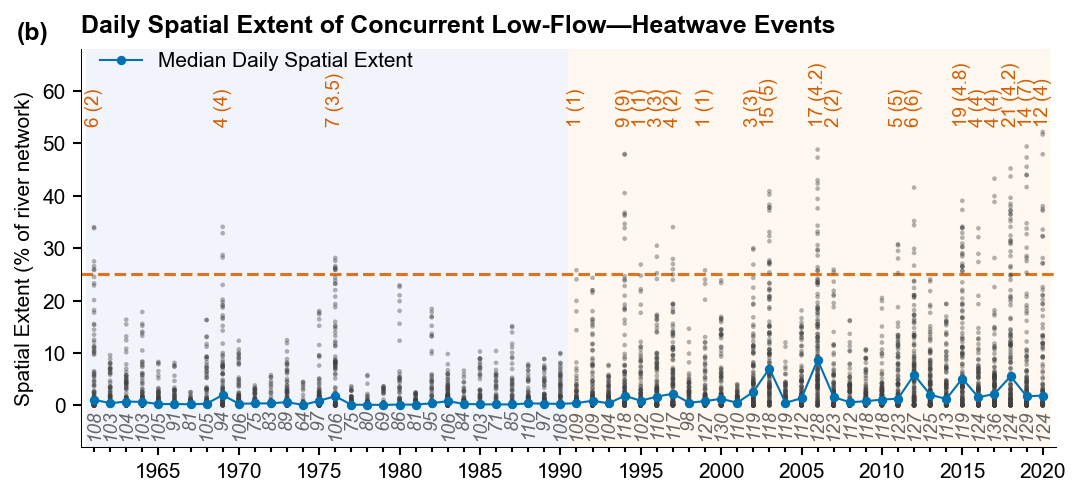

✓ Figure saved: Fig4_b_1


In [59]:
# Publication style settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 10,
    'axes.labelsize': 10,      # Changed from 8 to 10
    'axes.titlesize': 12,      # Changed from 10 to 12
    'xtick.labelsize': 10,     # Changed from 8 to 10
    'ytick.labelsize': 10,     # Changed from 8 to 10
    'legend.fontsize': 10,     # Changed from 8 to 10
    'lines.linewidth': 0.5,
    'axes.linewidth': 0.5,
})

# Figure size (inches)
FIG_WIDTH = 7.09
FIG_HEIGHT = 3.2

# Create figure with single plot
fig, ax1 = plt.subplots(1, 1, figsize=(FIG_WIDTH, FIG_HEIGHT))

# Add background colors for the two periods
# 1961-1990: Very subtle cool gray-blue
ax1.axvspan(-0.5, 29.49999, facecolor='#E8EEF7', alpha=0.6, zorder=0)
# 1991-2020: Very subtle warm gray
ax1.axvspan(29.5, 59.499, facecolor='#FFF4E6', alpha=0.6, zorder=0)

# Prepare data for violin plot
violin_data = []
for _, row in yearly_stats.iterrows():
    year = row['year']
    fractions = row['all_fractions']
    for fraction in fractions:
        violin_data.append({'year': year, 'fraction': fraction * 100})  # Convert to percentage

violin_df = pd.DataFrame(violin_data)
violin_df['year'] = violin_df['year'].astype(str)
yearly_stats['year'] = yearly_stats['year'].astype(str)

# Overlay points with fixed size = 5
sns.scatterplot(
    data=violin_df,
    x='year',
    y='fraction',
    ax=ax1,
    s=5,
    color='#404040',  # Dark gray instead of pure black
    ec='none',        # No edge color for cleaner look
    alpha=0.4,
    legend=False,
    zorder=5
)

# Add horizontal dashed line at 25% - using a distinct orange-red
ax1.axhline(y=25, color='#D55E00', linestyle='--', linewidth=1.5, alpha=0.85, zorder=1)

# Overlay Q75 line - using a professional blue
ax1.plot(
    range(len(yearly_stats)),
    yearly_stats['median'].values * 100,  # Convert to percentage
    marker='o',
    markersize=3,
    markerfacecolor='#0072B2',  # Filled marker color
    markeredgecolor='#0072B2',  # Edge color
    markeredgewidth=1.5,
    label='Median Daily Spatial Extent',
    linewidth=1,
    color='#0072B2',
    zorder=10,
    alpha=1
)

# Annotate number of days above 0.25 threshold with mean duration (TOP)
y_max = violin_df['fraction'].max()
for i, row in yearly_stats.iterrows():
    n_days_above = row['n_days_above_0p25']
    mean_dur = row['mean_duration_above_0p25']
    
    if n_days_above > 0:
        if mean_dur == int(mean_dur):
            dur_text = f"{int(mean_dur)}"
        else:
            dur_text = f"{mean_dur:.1f}"
        
        annotation_text = f"{int(n_days_above)} ({dur_text})"
        
        # Use same color as horizontal line for consistency
        ax1.text(i, y_max * 1.02, annotation_text, 
                rotation=90, ha='center', va='bottom',
                fontsize=9, fontweight='normal', color='#D55E00')  # Changed from 7 to 9

# Annotate number of windows for each year (BOTTOM)
for i, row in yearly_stats.iterrows():
    n_dates = row['n_dates']
    if n_dates > 0:
        ax1.text(
            i, -0.7, str(int(n_dates)),  # Adjusted for percentage scale
            rotation=90, ha='center', va='top',
            fontsize=9, fontstyle='italic', color='#666666')  # Changed from 6 to 9

ax1.set_ylabel('Spatial Extent (% of river network)', fontsize=10, fontweight='normal')
ax1.set_xlabel('')

# Update legend with specified parameters
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95,
           frameon=False,
          edgecolor='gray', fancybox=False,
          bbox_to_anchor=(0.0, 1.04))  # ← increase second value to nudge higher


# --- Title: on the right, no panel label ---
ax1.set_title(
    'Daily Spatial Extent of Concurrent Low-Flow\u2014Heatwave Events',
    #'Annual Spatiotemporal Extent of Compound Events',
    fontsize=12, fontweight='bold', ha='left', x=0.0, pad=8)

# Set y-axis limits in percentage (multiply by 100)
ax1.set_ylim(-8, 68)

# Set x-axis limits
ax1.set_xlim(-0.8, 59.8)  # Adjusted for 0-indexed positions

# Set ticks at every 5-year interval starting from 1965
# Find the indices corresponding to years 1965, 1970, 1975, etc.
year_values = yearly_stats['year'].astype(int).values
tick_years = list(range(1965, 2025, 5))  # 1965, 1970, 1975, ..., 2020
tick_positions = []
tick_labels = []

for tick_year in tick_years:
    if tick_year in year_values:
        idx = np.where(year_values == tick_year)[0][0]
        tick_positions.append(idx)
        tick_labels.append(str(tick_year))

ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=0, fontsize=10)  # Changed from 8 to 10

# Add minor ticks at every year
all_year_positions = list(range(len(yearly_stats)))
ax1.set_xticks(all_year_positions, minor=True)

# Customize tick appearance - width=1, length=4 for major ticks
ax1.tick_params(axis='x', which='minor', length=2.5, width=1, direction='out')
ax1.tick_params(axis='x', which='major', length=4, width=1, direction='out')
ax1.tick_params(axis='y', which='major', length=4, width=1, direction='out')

# --- Hide top and right spines ---
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Panel label: rightmost side ---
ax1.text(
    -0.05, 1.07, '(b)',          # ← increase second value to move up
    transform=ax1.transAxes,
    fontsize=12, fontweight='bold',
    va='top', ha='center'
)

#plt.tight_layout()
plt.show()

# Save figure
Save_dir = FIGURE_DIR
savename = f'Fig4_b_{TEMPORAL_WINDOW}'
if savename:
    os.makedirs(Save_dir, exist_ok=True)
    fig.savefig(os.path.join(Save_dir, f'{savename}.pdf'), 
               format='pdf', bbox_inches='tight')
    print(f"✓ Figure saved: {savename}")
    plt.close(fig)